Repository: /Users/yitxuenglim/Downloads/mjlab-trained
Output:     /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/eval_plots
Reference families discovered: 15
Crawlstand {'DSMS': 'crawlstand1.npz', 'GhostGUI': 'crawlstand1gg.npz'}
Crouch {'DSMS': 'crouch.npz', 'GhostGUI': 'crouchgg.npz'}
Facedown {'DSMS': 'facedown.npz', 'GhostGUI': 'facedowngg.npz'}
Facedown1 {'DSMS': 'facedown1.npz', 'GhostGUI': 'facedown1gg.npz'}
Getup {'DSMS': 'getup.npz'}
Kneel {'DSMS': 'kneel.npz'}
Lunges {'DSMS': 'lunges.npz'}
Lunges2 {'DSMS': 'lunges2.npz', 'GhostGUI': 'lunges2gg.npz'}
Lunges3 {'DSMS': 'lunges3.npz', 'GhostGUI': 'lunges3gg.npz'}
Pushup {'DSMS': 'pushup2.npz', 'GhostGUI': 'pushupgg.npz'}
Slidefloat {'DSMS': 'slidefloat.npz'}
Squat {'DSMS': 'squat.npz', 'GhostGUI': 'squatgg.npz'}
Theworm {'DSMS': 'theworm2.npz', 'GhostGUI': 'theworm1gg.npz'}
Twerk {'DSMS': 'twerk.npz', 'GhostGUI': 'twerkgg.npz'}
Worm1 {'DSMS': 'worm1.npz', 'GhostGUI': 'worm1gg.npz'}
Saved logs/dsms_analysis/eval_pl

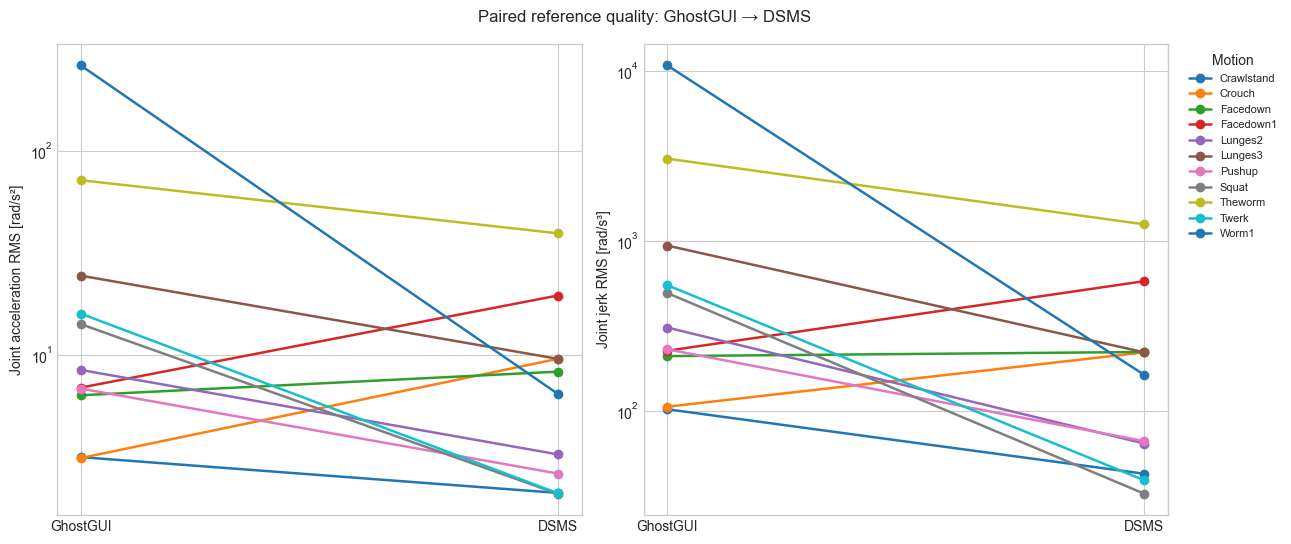


Clean rollouts discovered: 21
crawlstand_contactrich              Crawlstand DSMS Contact-rich 30000
crawlstand                          Crawlstand DSMS Standard 20000
crawlstandgg                        Crawlstand GhostGUI Standard 20000
facedown                            Facedown DSMS Custom 30000
facedowngg                          Facedown GhostGUI Custom 30000
getup_custom_4500                   Getup DSMS Custom 4500
getup                               Getup DSMS Standard 30000
kneel                               Kneel DSMS Standard 20000
lunges2_custom                      Lunges2 DSMS Custom 30000
lunges2                             Lunges2 DSMS Standard 20000
lunges2gg                           Lunges2 GhostGUI Standard 20000
lunges                              Lunges DSMS Standard 20000
pushup                              Pushup DSMS Custom 30000
pushupgg                            Pushup GhostGUI Custom 30000
slidefloat                          Slidefloat DSMS Standard 200

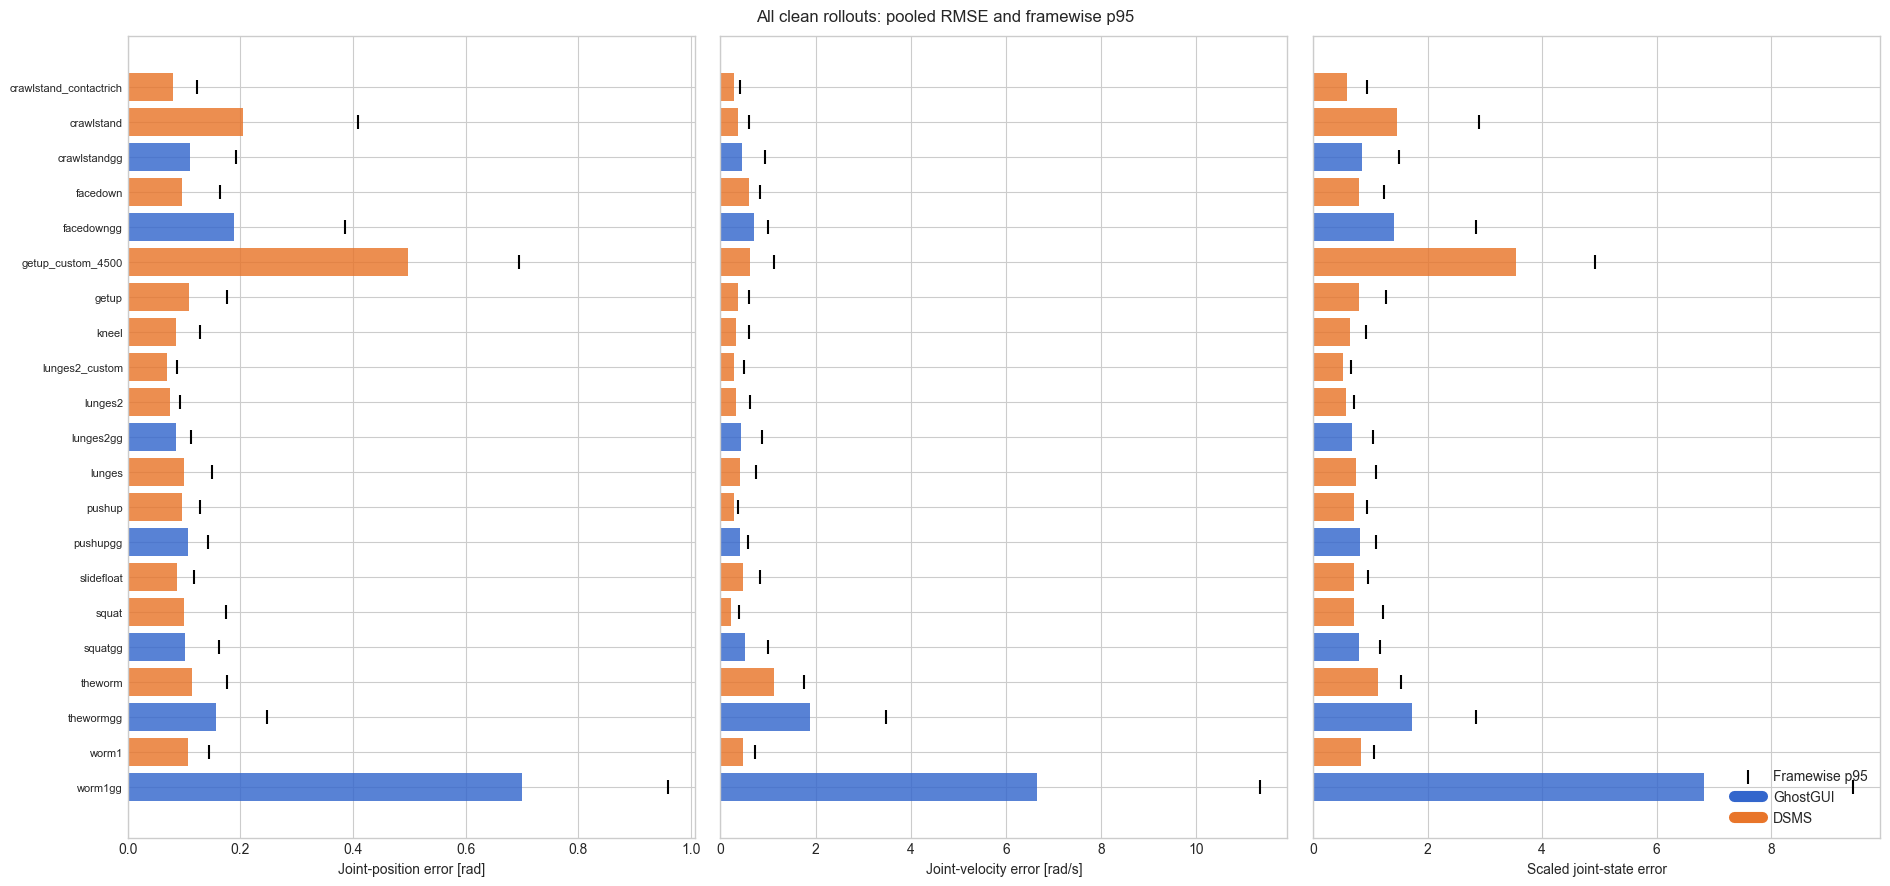

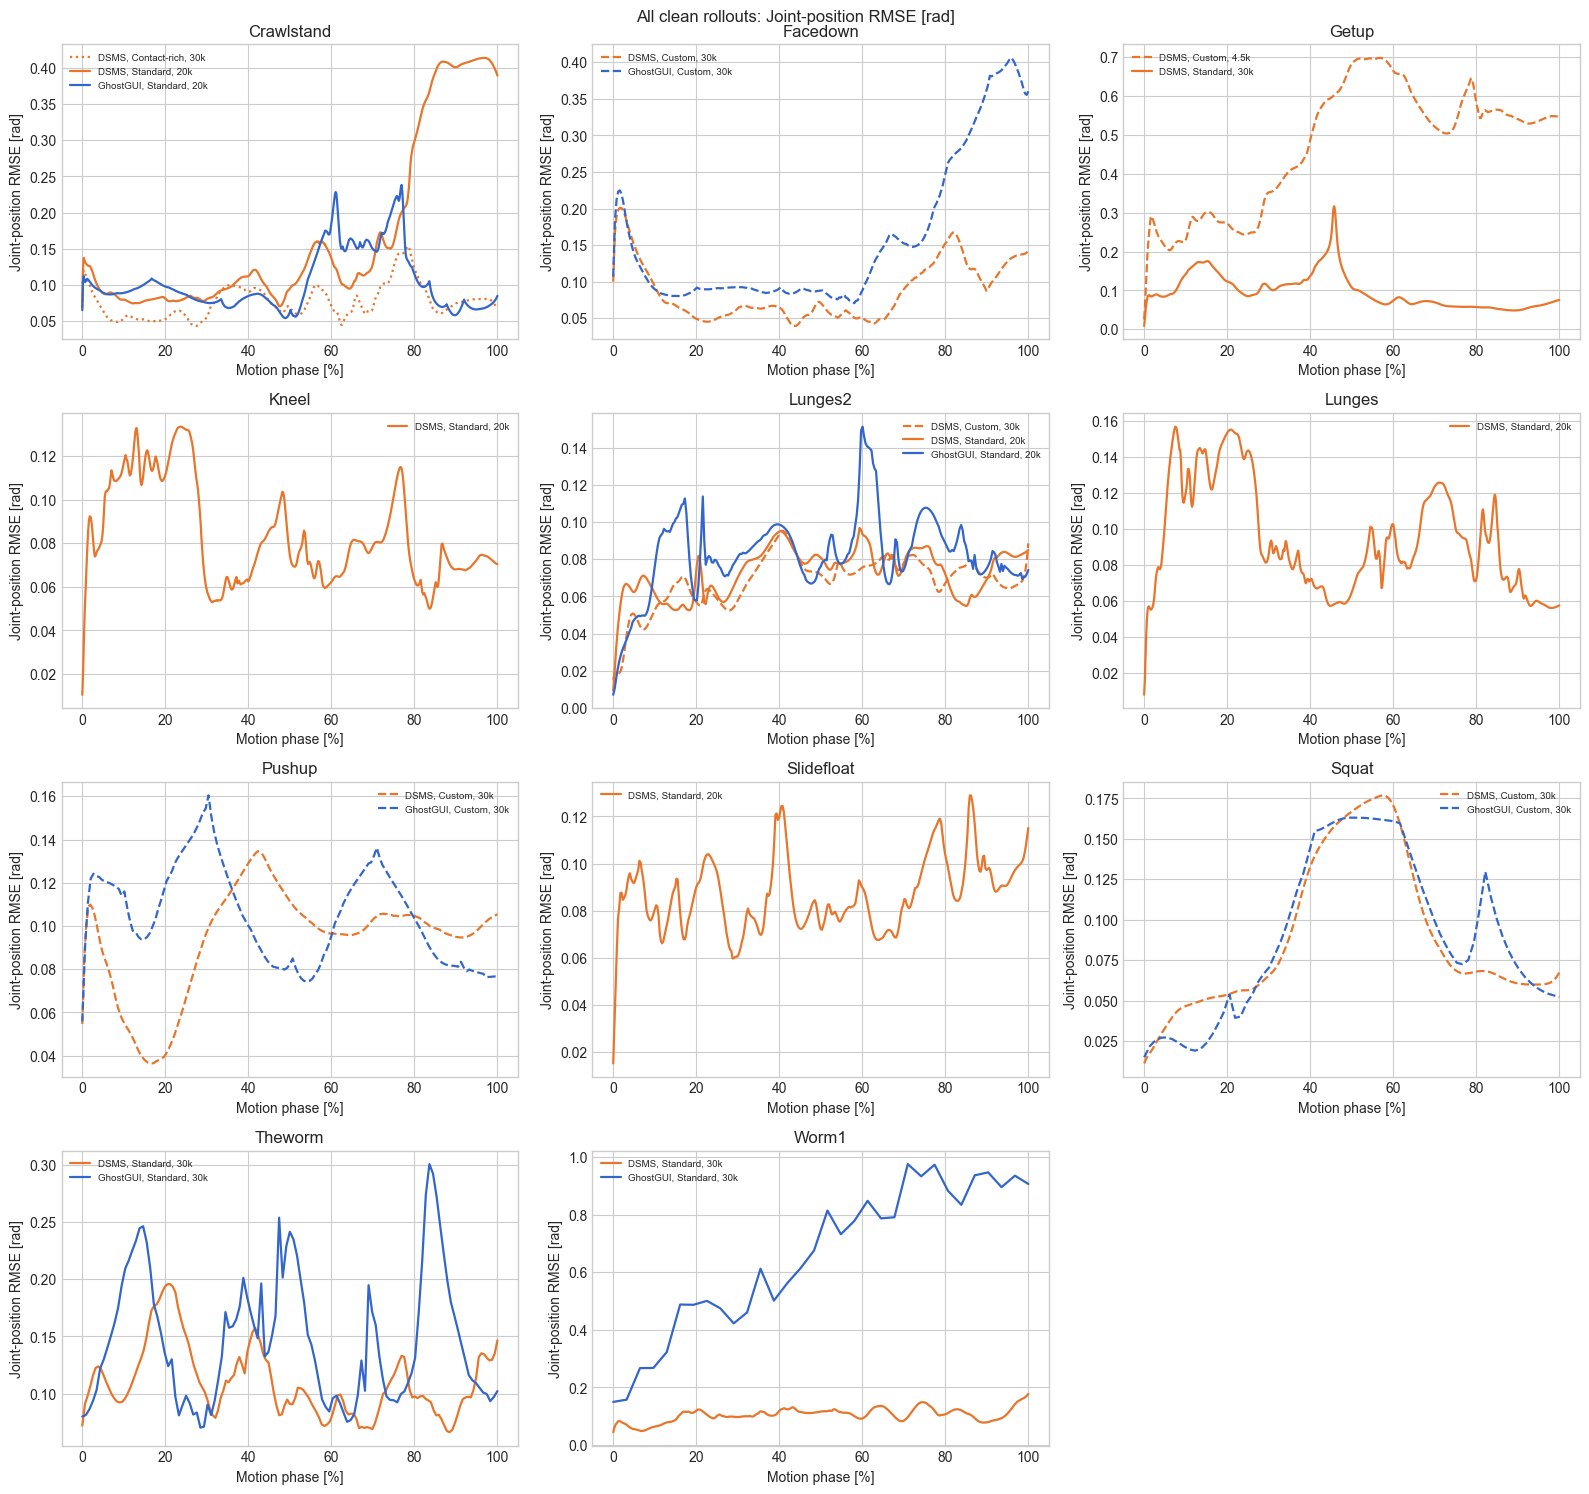

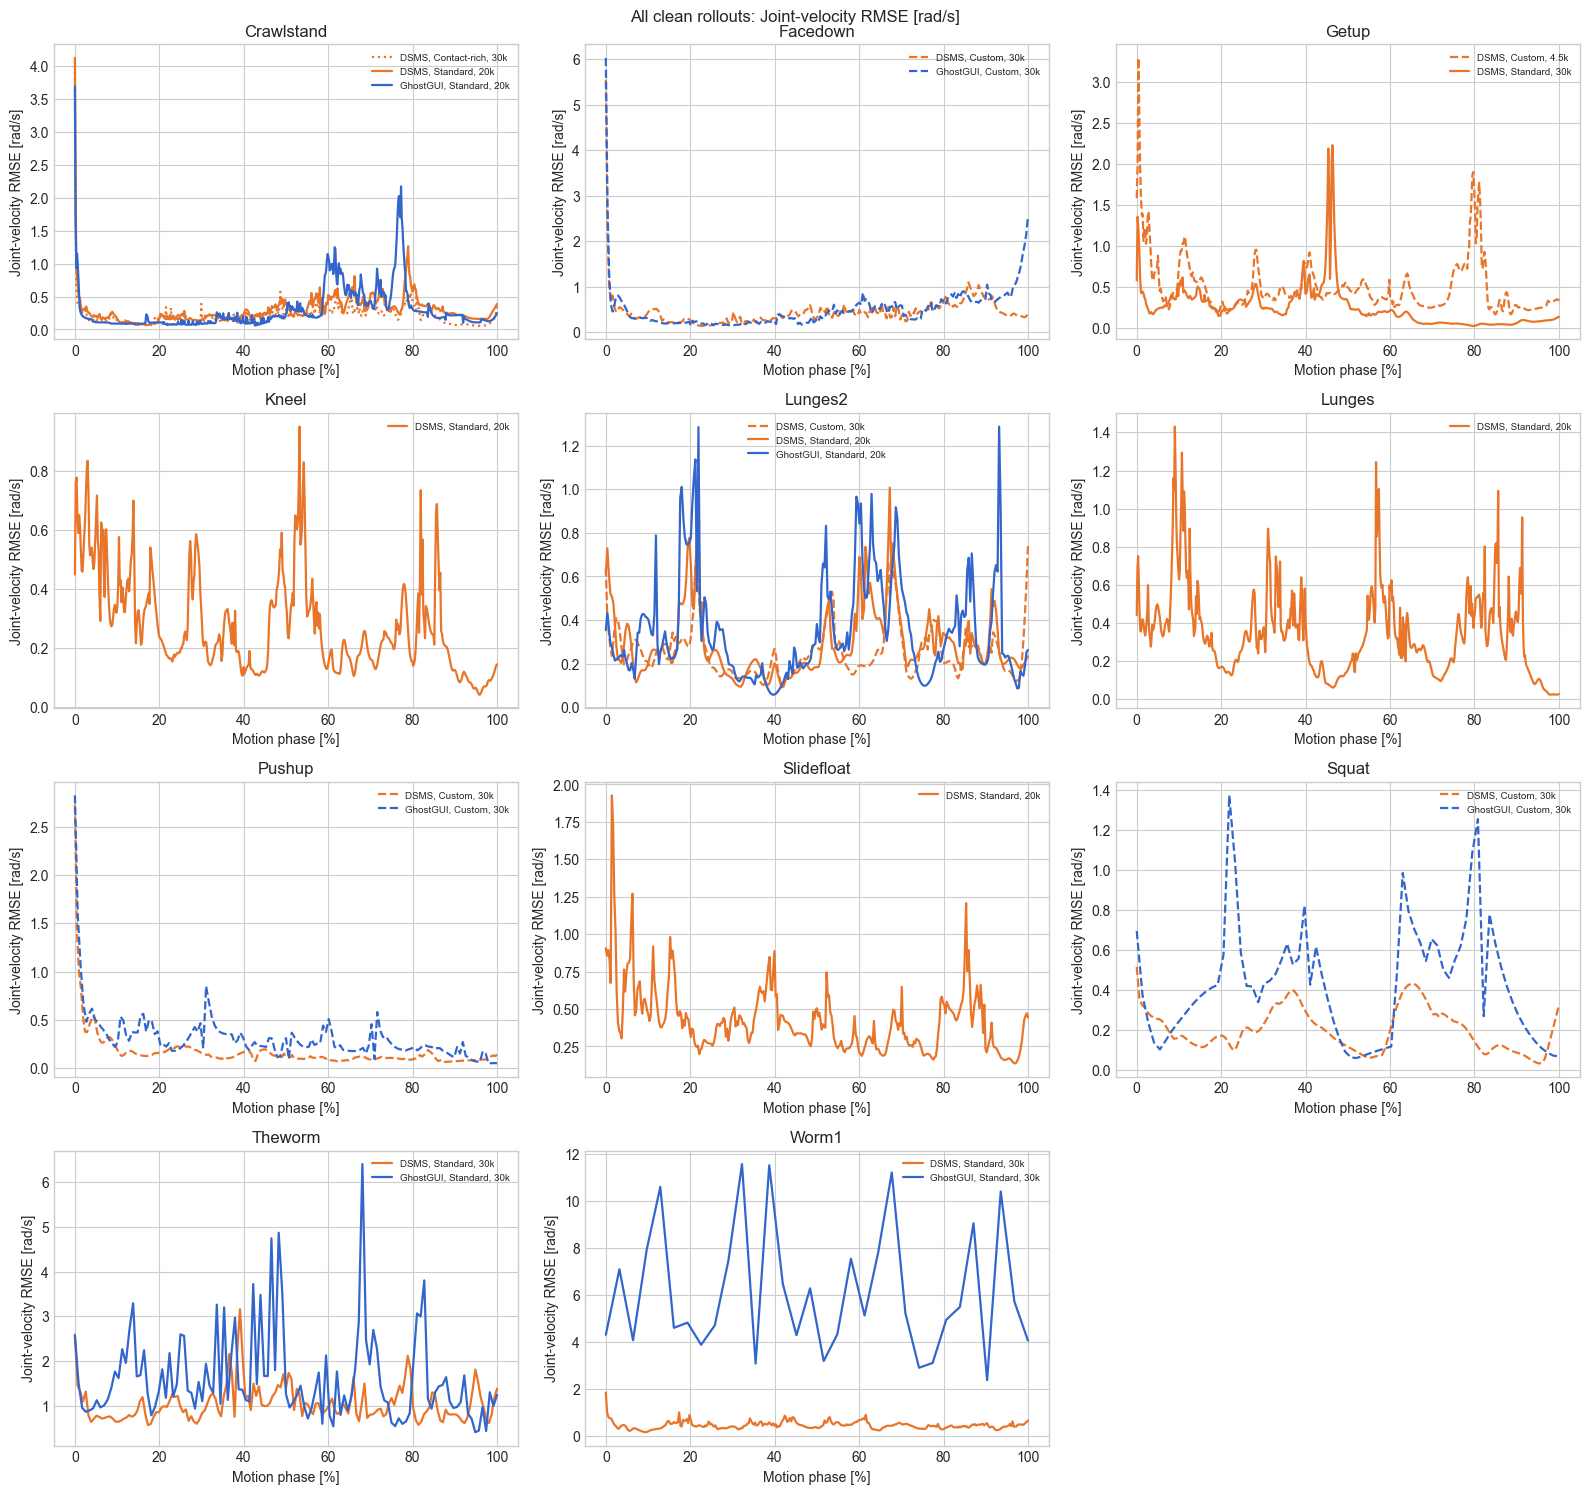

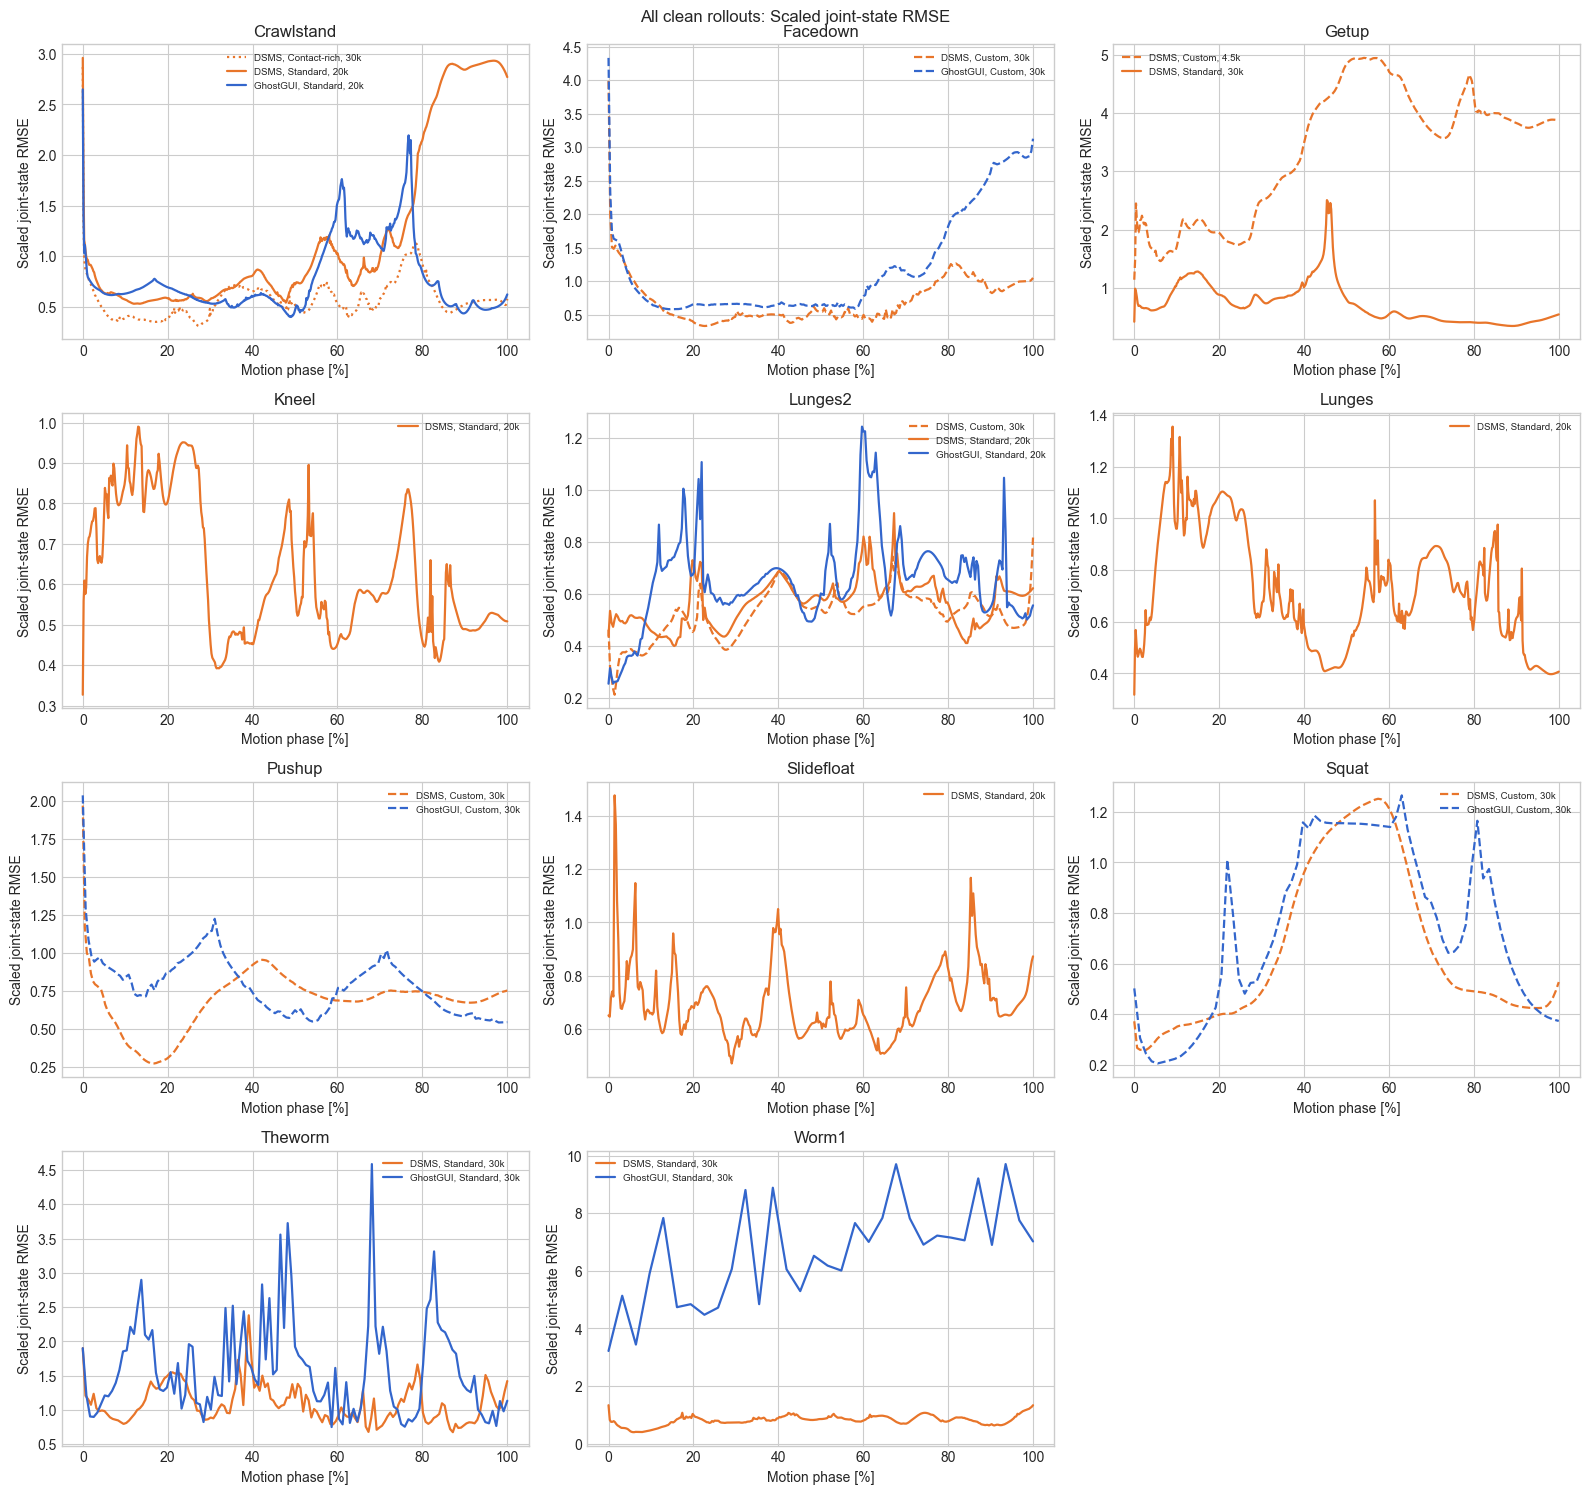


Local TensorBoard learning runs: 21
Unified learning runs: 34

Learning families: ['Crawlstand', 'Crouch', 'Facedown', 'Facedown1', 'Getup', 'Lunges', 'Lunges2', 'Lunges3', 'Pushup', 'Slidefloat', 'Squat', 'Theworm', 'Worm1']


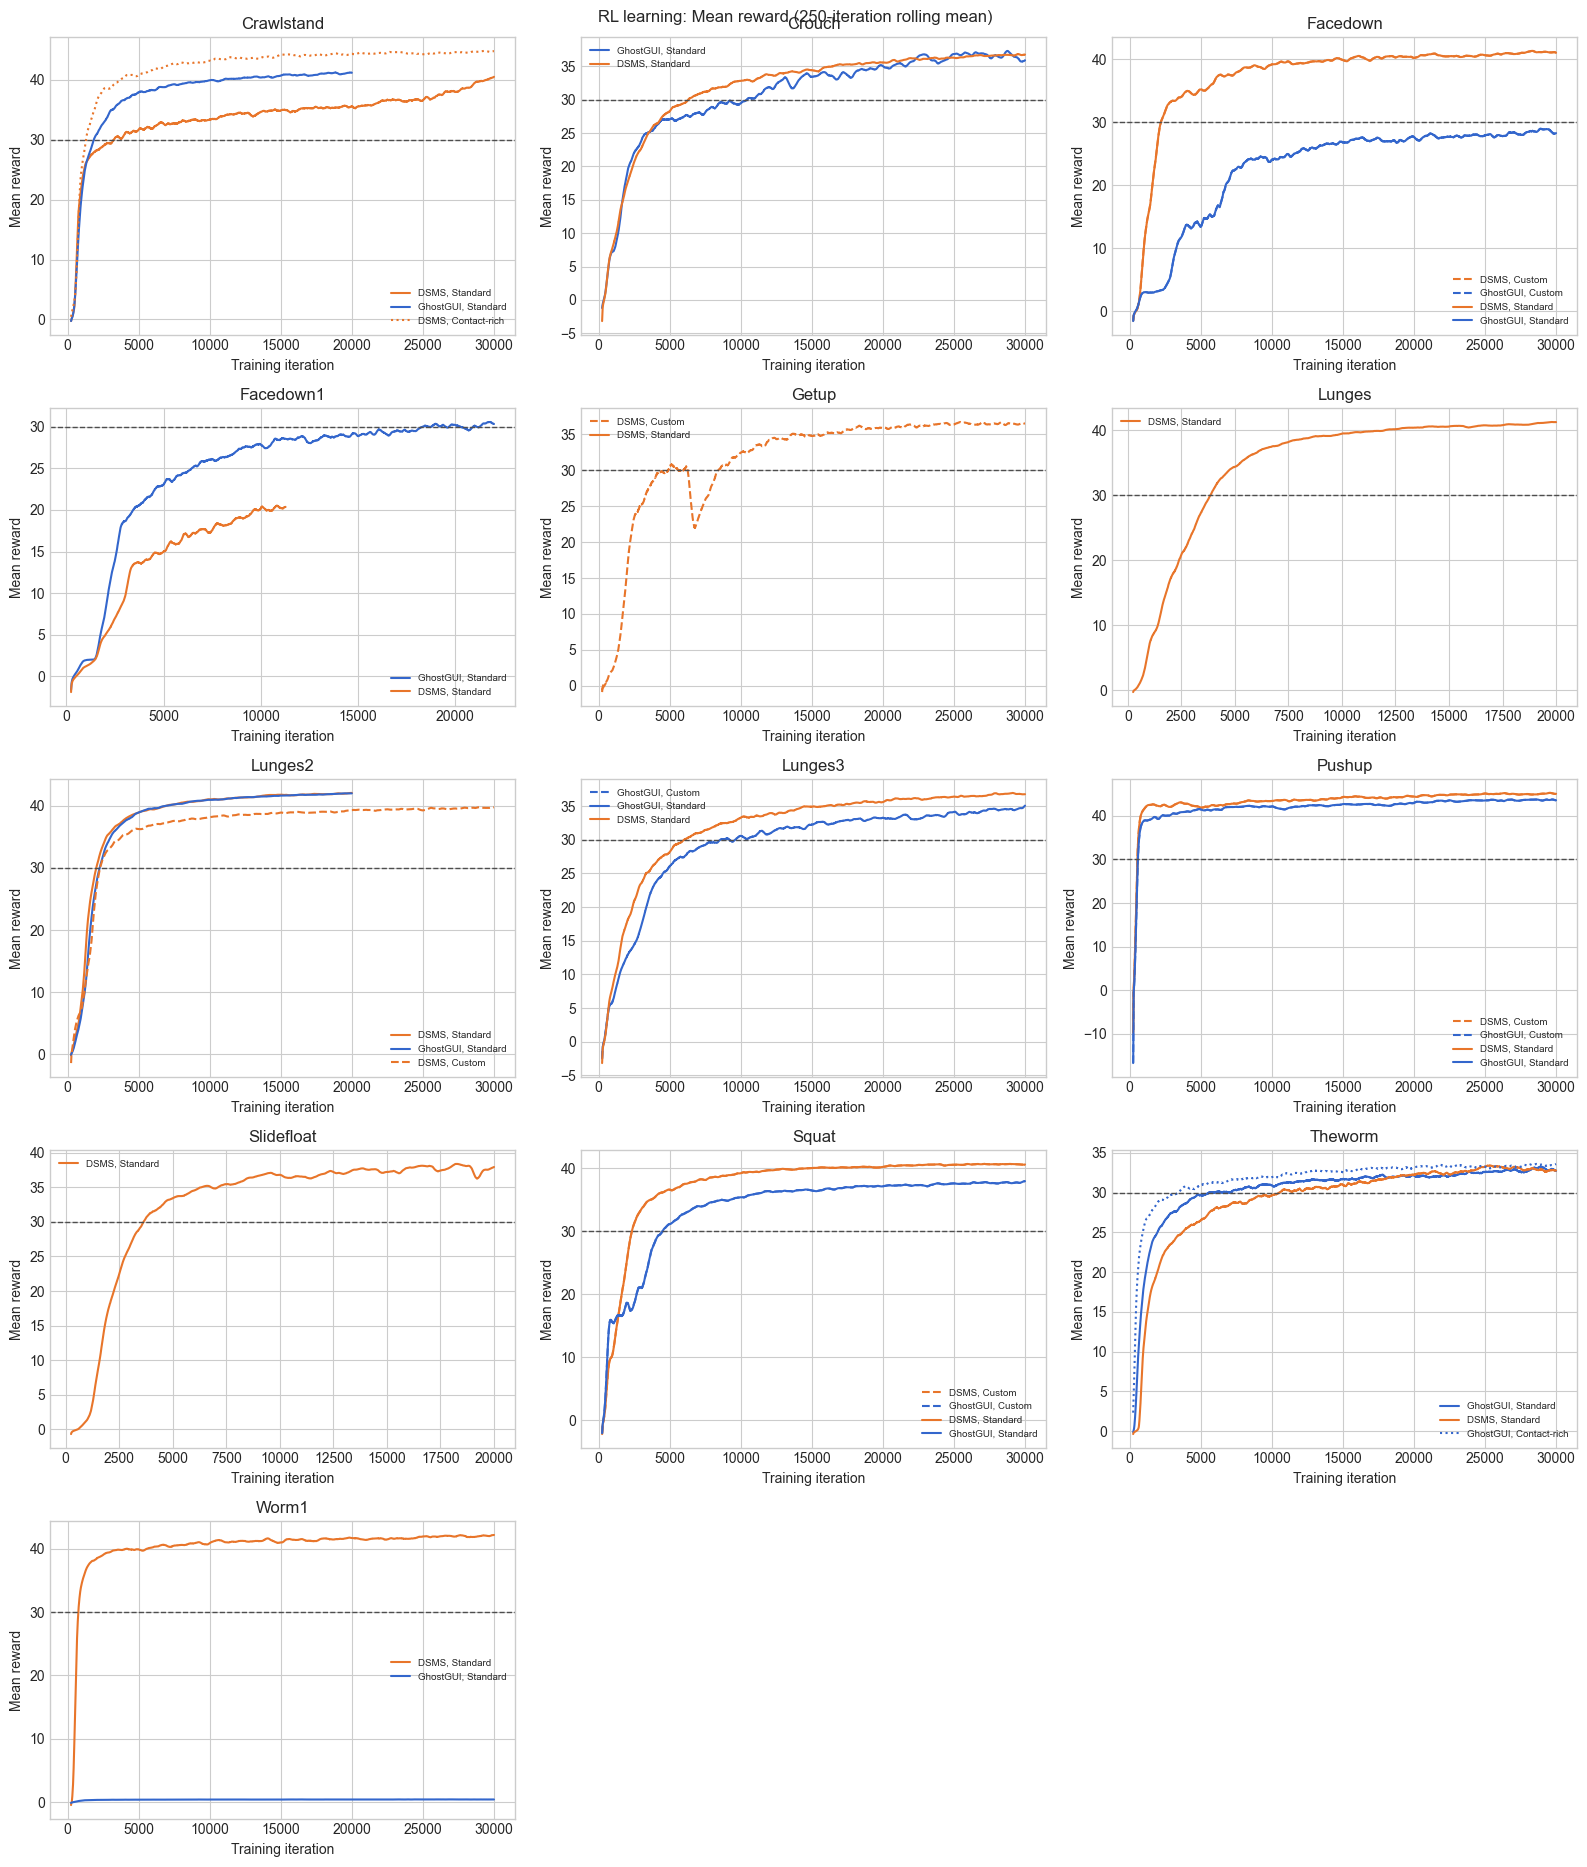

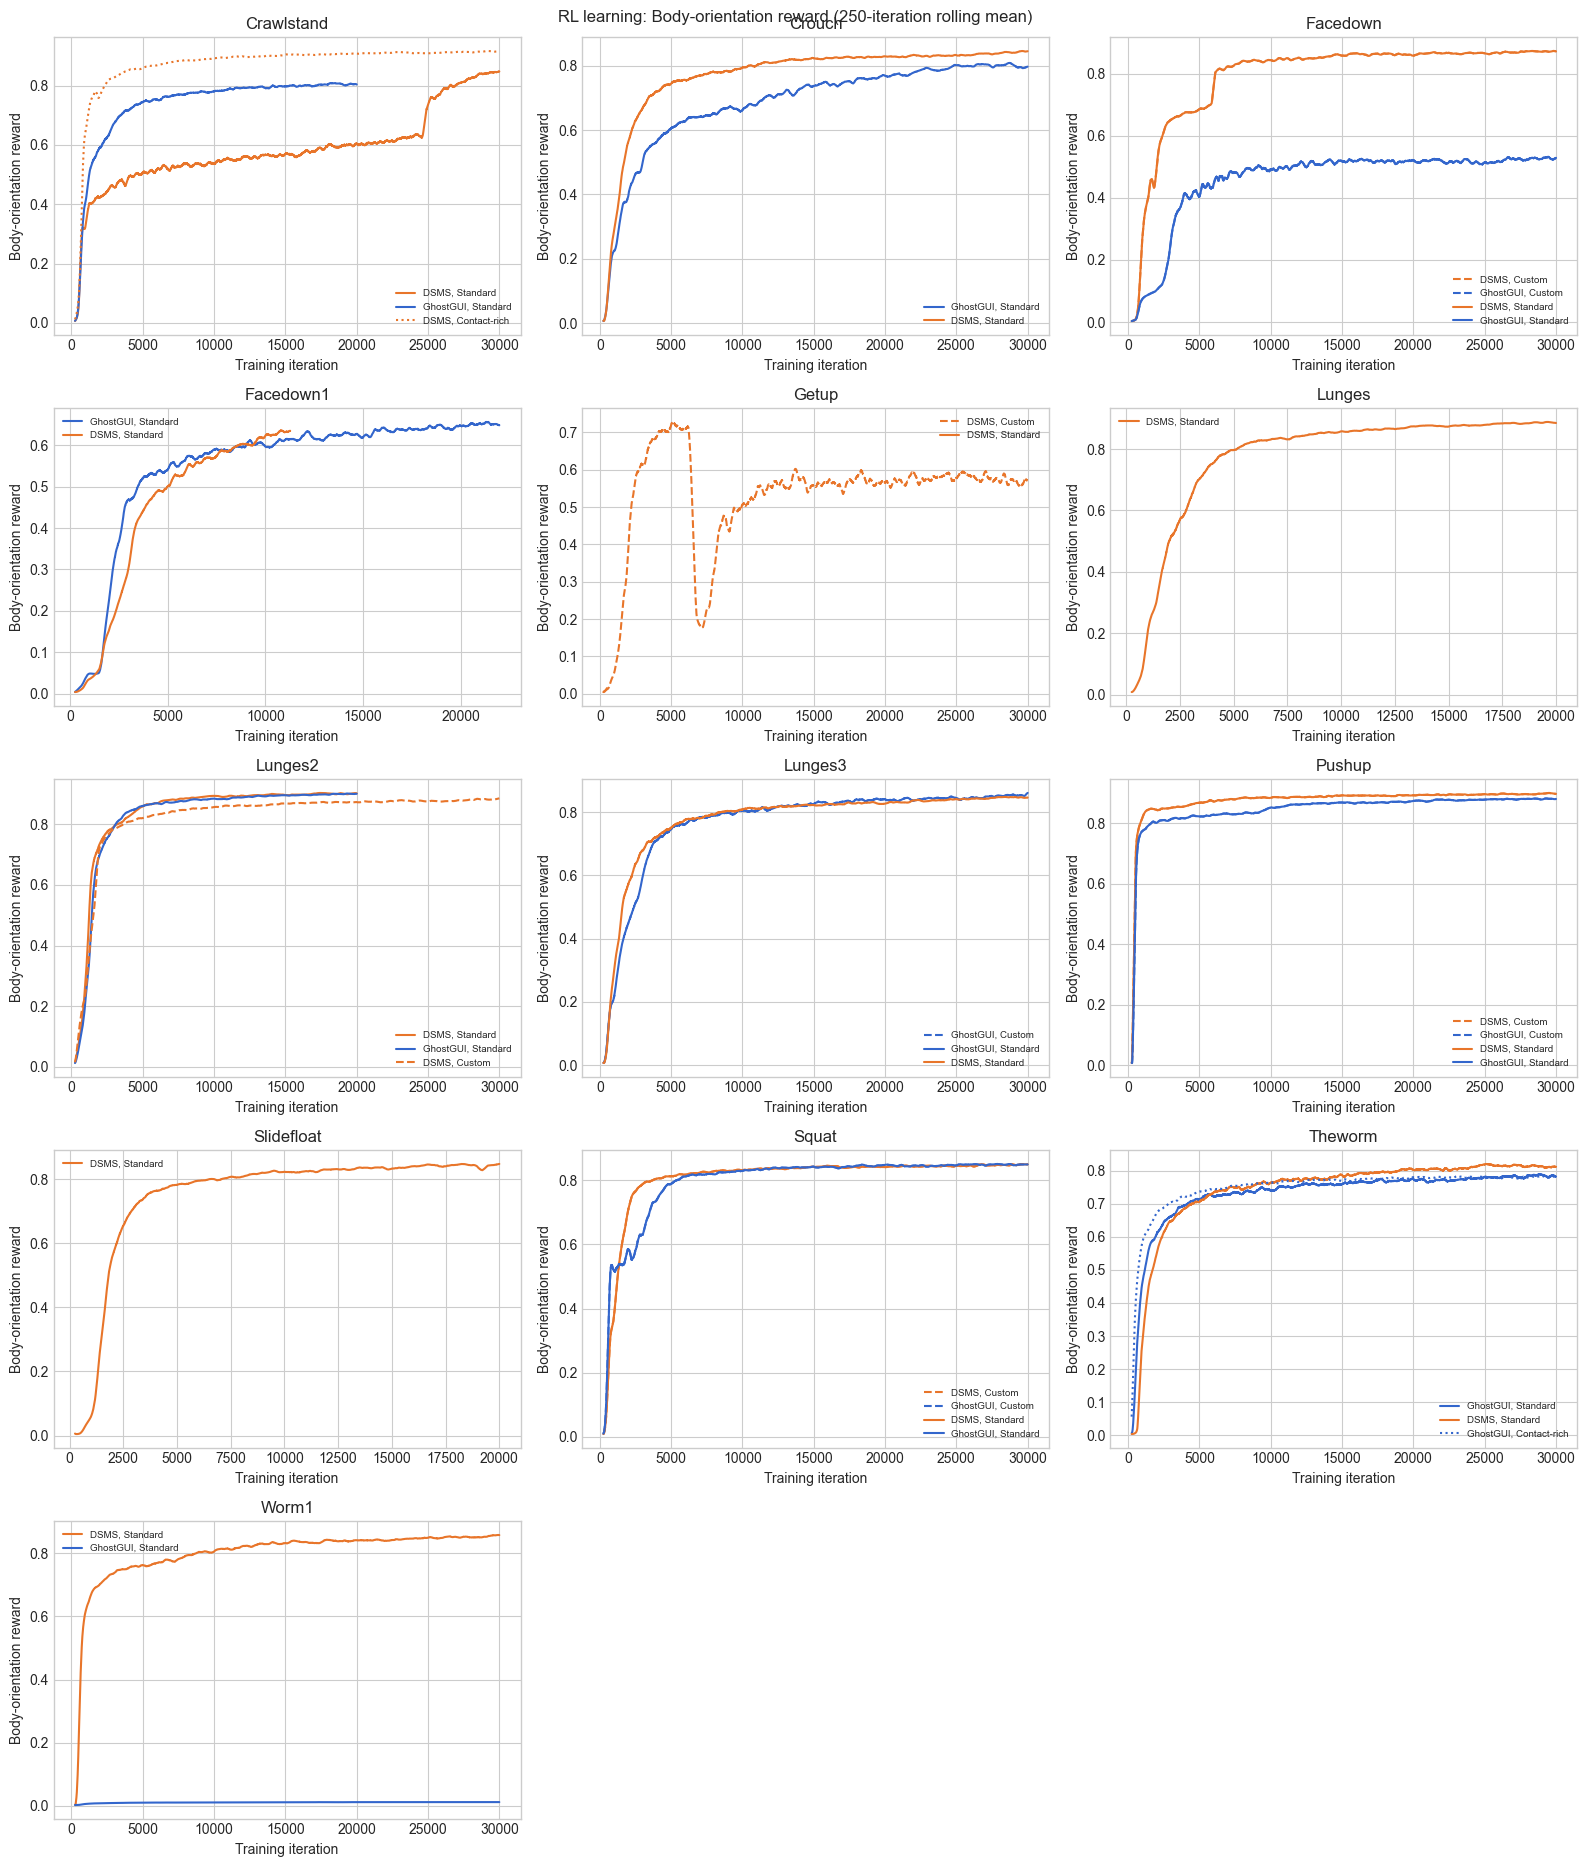

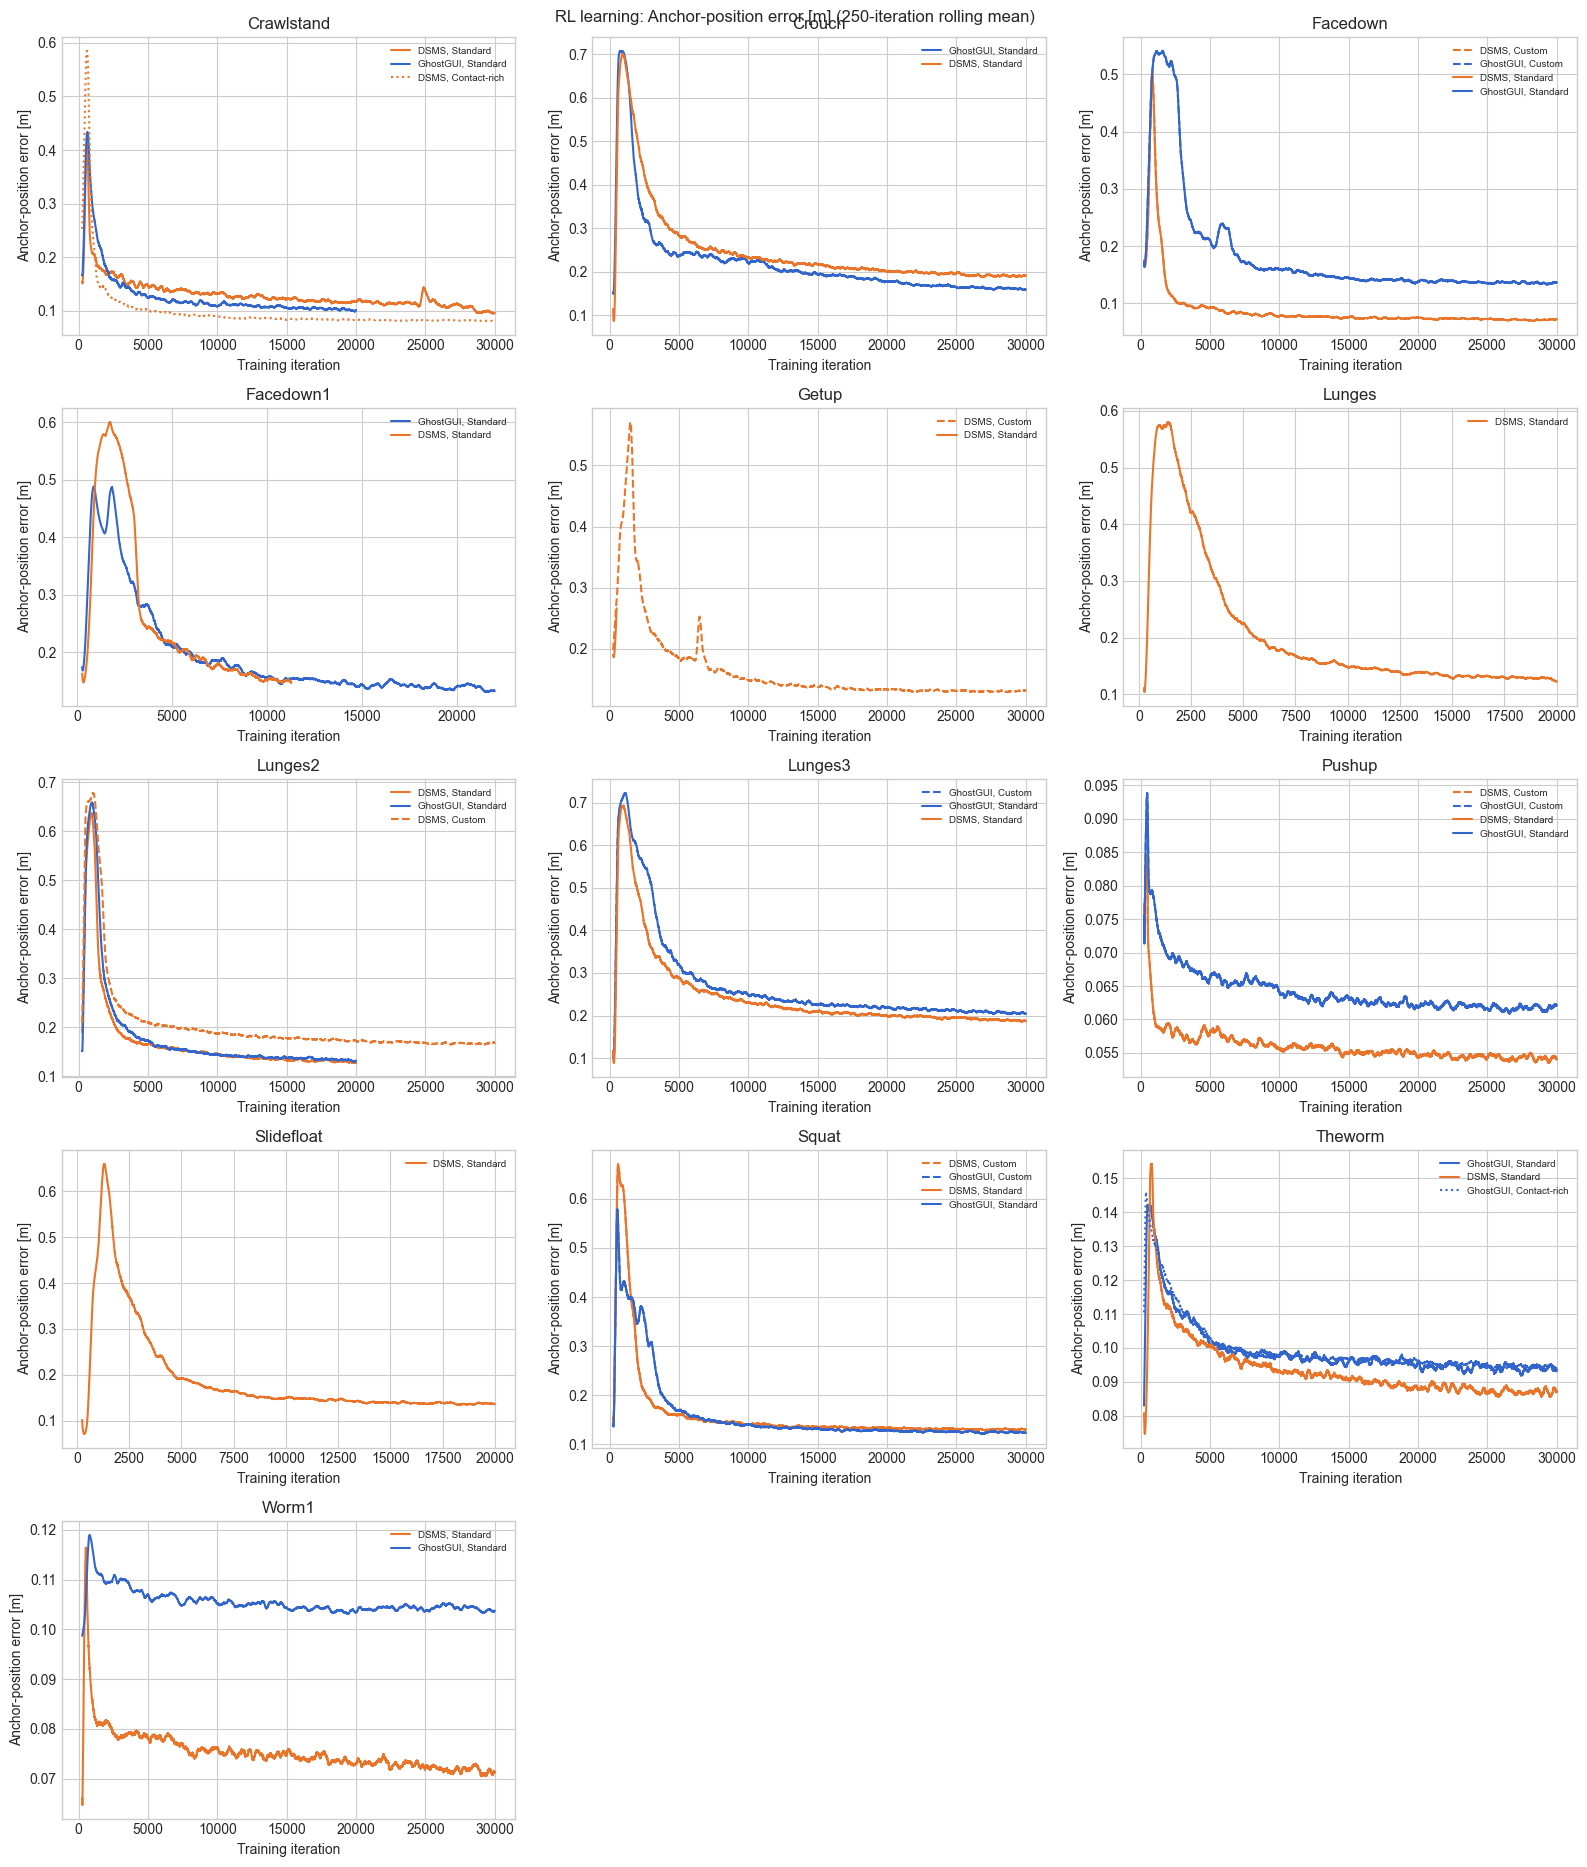

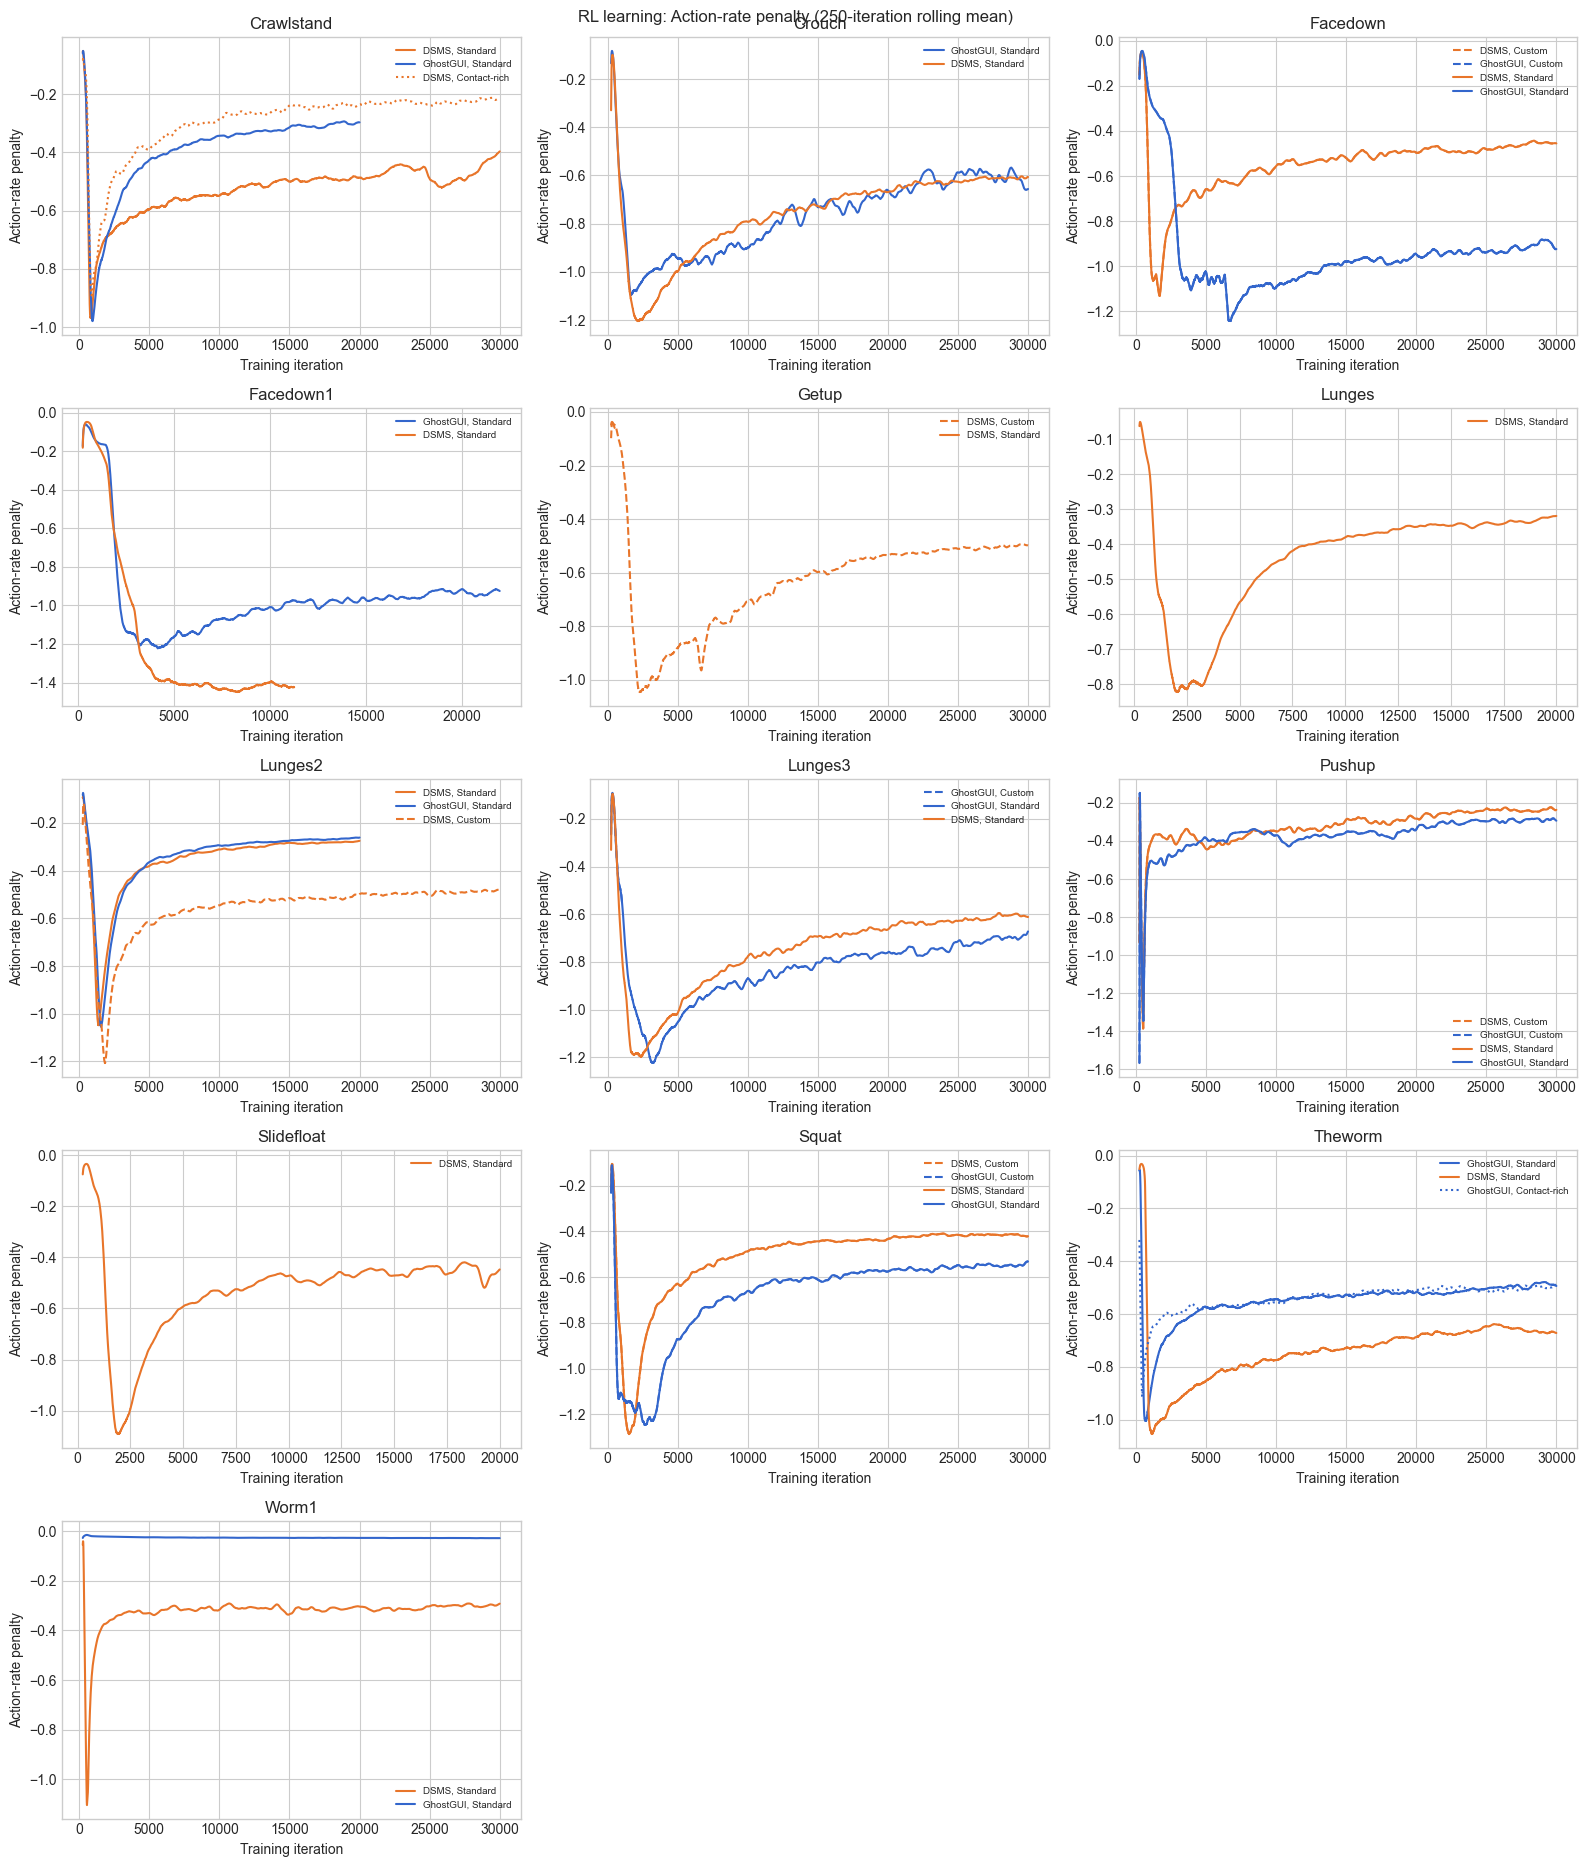

Saved logs/dsms_analysis/eval_plots/learning_efficiency.csv


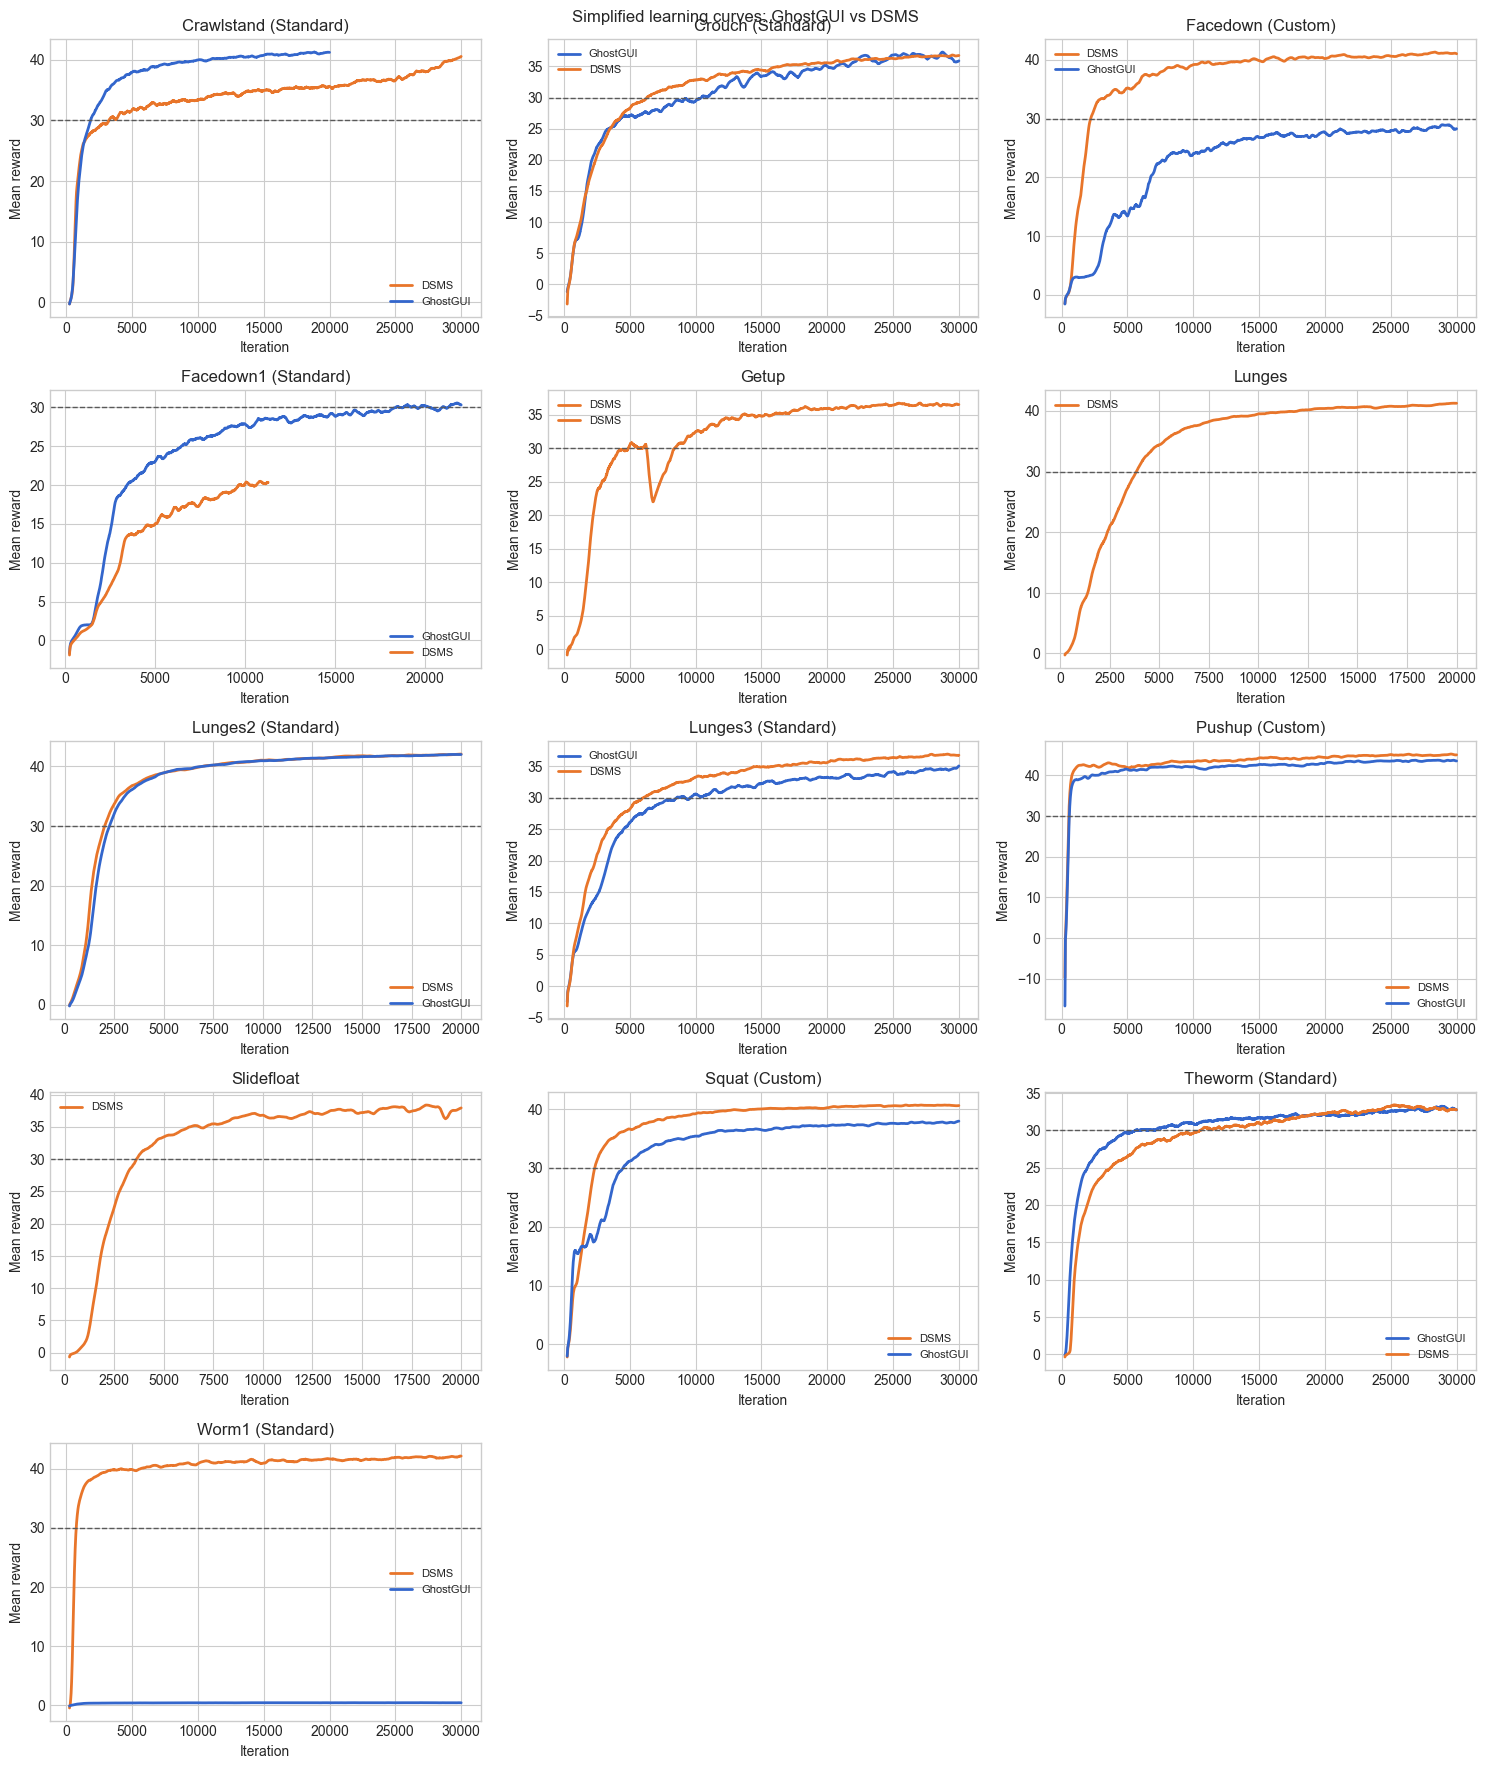

Saved logs/dsms_analysis/eval_plots/paired_rollout_comparison.csv


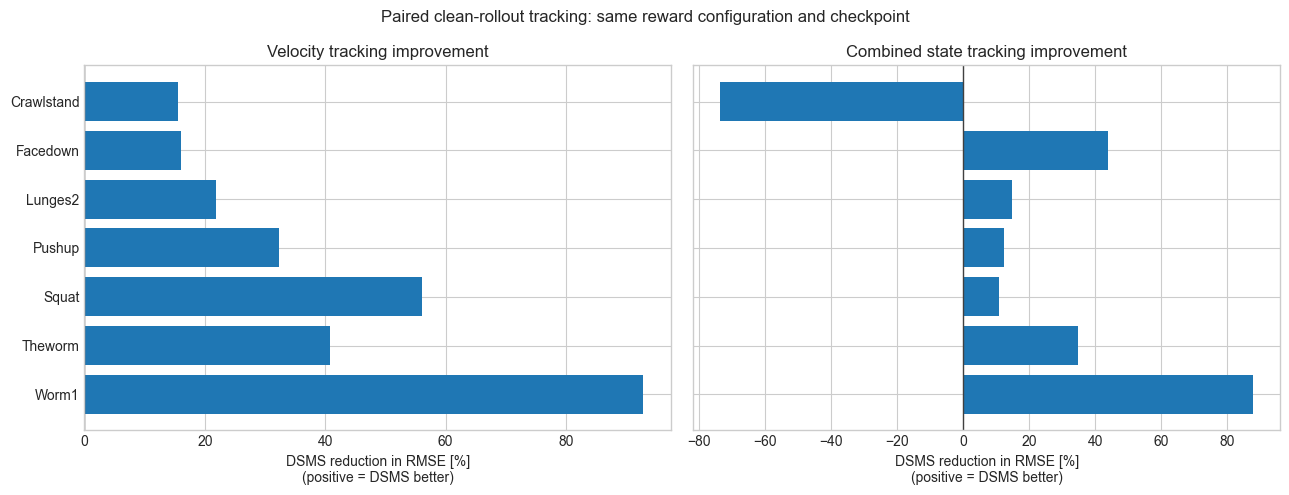

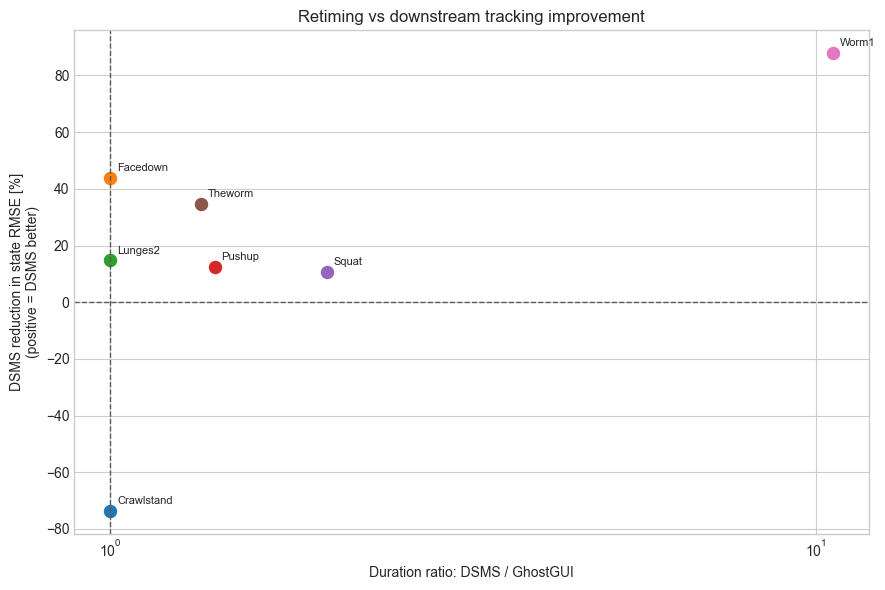

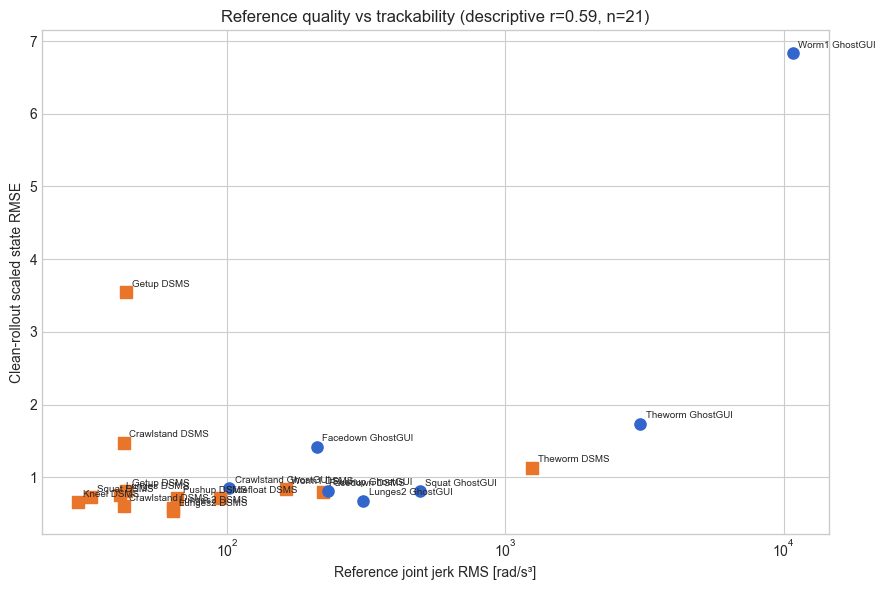


Generated files:
  logs/dsms_analysis/eval_plots/all_trace_evaluation.csv
  logs/dsms_analysis/eval_plots/all_trace_rmse_summary.png
  logs/dsms_analysis/eval_plots/all_traces_position_rmse.png
  logs/dsms_analysis/eval_plots/all_traces_state_rmse.png
  logs/dsms_analysis/eval_plots/all_traces_velocity_rmse.png
  logs/dsms_analysis/eval_plots/learning_action_rate_penalty.png
  logs/dsms_analysis/eval_plots/learning_anchor_position_error_m.png
  logs/dsms_analysis/eval_plots/learning_body_orientation_reward.png
  logs/dsms_analysis/eval_plots/learning_curves_simplified.png
  logs/dsms_analysis/eval_plots/learning_efficiency.csv
  logs/dsms_analysis/eval_plots/learning_mean_reward.png
  logs/dsms_analysis/eval_plots/paired_rollout_comparison.csv
  logs/dsms_analysis/eval_plots/paired_tracking_improvement.png
  logs/dsms_analysis/eval_plots/quality_vs_trackability.png
  logs/dsms_analysis/eval_plots/reference_quality.csv
  logs/dsms_analysis/eval_plots/reference_quality_paired.png
  logs

In [3]:
# %%
"""
Unified GhostGUI / DSMS / RL evaluation notebook.

Open in VS Code as a Jupyter-style Python notebook using the # %% cells,
or run directly:

    python notebooks/eval_plots.py

Main differences from notebooks/wandb.ipynb:
1. Automatically discovers all available motion/reference pairs.
2. Automatically discovers all clean-rollout trace CSVs.
3. Automatically discovers all local RL training histories.
4. Does not restrict learning analysis to the original six W&B runs.
5. Adds presentation-focused plots:
   - paired_tracking_improvement.png
   - learning_curves_simplified.png
   - retiming_vs_state_improvement.png

Outputs:
    logs/dsms_analysis/eval_plots/
"""

from __future__ import annotations

import csv
import json
import math
import re
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np

# %%
# ---------------------------------------------------------------------------
# Repository setup
# ---------------------------------------------------------------------------


def find_repo_root(start: Path | None = None) -> Path:
  start = (start or Path.cwd()).resolve()

  for candidate in (start, *start.parents):
    if (candidate / "pyproject.toml").is_file():
      return candidate

  raise FileNotFoundError(
    "Run this notebook somewhere inside the mjlab-trained repository."
  )


ROOT = find_repo_root()

MOTION_DIR = ROOT / "motion"
LOG_DIR = ROOT / "logs"
TRAIN_DIR = LOG_DIR / "rsl_rl"

OUTPUT_DIR = LOG_DIR / "dsms_analysis" / "eval_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


POSITION_ERROR_SCALE_RAD = 0.1
VELOCITY_ERROR_SCALE_RAD_S = 1.0

SMOOTHING_WINDOW_ITERATIONS = 250
FINAL_WINDOW_ITERATIONS = 1_000
THRESHOLD_HOLD_ITERATIONS = 250
MIN_THRESHOLD_ITERATION = 1_000

MEAN_REWARD_THRESHOLD = 30.0


CONDITIONS = ("GhostGUI", "DSMS")

CONDITION_COLORS = {
  "GhostGUI": "#3366CC",
  "DSMS": "#E8752A",
}

CONDITION_MARKERS = {
  "GhostGUI": "o",
  "DSMS": "s",
}

CONFIG_LINESTYLES = {
  "Standard": "-",
  "Custom": "--",
  "Contact-rich": ":",
}


plt.style.use("seaborn-v0_8-whitegrid")

print(f"Repository: {ROOT}")
print(f"Output:     {OUTPUT_DIR}")


# %%
# ---------------------------------------------------------------------------
# Known reference pairs
#
# Keep this table because some filenames are asymmetric:
# pushup2 vs pushupgg, theworm2 vs theworm1gg, etc.
#
# Add future pairs here if naming is ambiguous.
# ---------------------------------------------------------------------------

REFERENCE_PAIRS: dict[str, tuple[str, str]] = {
  "Crawlstand": (
    "crawlstand1.npz",
    "crawlstand1gg.npz",
  ),
  "Crouch": (
    "crouch.npz",
    "crouchgg.npz",
  ),
  "Facedown": (
    "facedown.npz",
    "facedowngg.npz",
  ),
  "Facedown1": (
    "facedown1.npz",
    "facedown1gg.npz",
  ),
  "Lunges2": (
    "lunges2.npz",
    "lunges2gg.npz",
  ),
  "Lunges3": (
    "lunges3.npz",
    "lunges3gg.npz",
  ),
  "Pushup": (
    "pushup2.npz",
    "pushupgg.npz",
  ),
  "Squat": (
    "squat.npz",
    "squatgg.npz",
  ),
  "Theworm": (
    "theworm2.npz",
    "theworm1gg.npz",
  ),
  "Twerk": (
    "twerk.npz",
    "twerkgg.npz",
  ),
  "Worm1": (
    "worm1.npz",
    "worm1gg.npz",
  ),
}


# Standalone DSMS references that may not currently have GG pairs.
STANDALONE_REFERENCES = {
  "getup.npz": "Getup",
  "kneel.npz": "Kneel",
  "lunges.npz": "Lunges",
  "slidefloat.npz": "Slidefloat",
}


FAMILY_BY_REFERENCE: dict[str, str] = {}

for family, (dsms_file, gg_file) in REFERENCE_PAIRS.items():
  FAMILY_BY_REFERENCE[dsms_file] = family
  FAMILY_BY_REFERENCE[gg_file] = family

FAMILY_BY_REFERENCE.update(STANDALONE_REFERENCES)


# %%
# ---------------------------------------------------------------------------
# Data structures
# ---------------------------------------------------------------------------


@dataclass(frozen=True)
class MotionData:
  path: Path
  fps: float
  joint_pos: np.ndarray
  joint_vel: np.ndarray
  body_pos_w: np.ndarray | None

  @property
  def duration_s(self) -> float:
    return (len(self.joint_pos) - 1) / self.fps


@dataclass(frozen=True)
class TraceData:
  time_s: np.ndarray

  q_ref: np.ndarray
  q_robot: np.ndarray

  v_ref: np.ndarray
  v_robot: np.ndarray

  scalars: dict[str, np.ndarray]

  @property
  def q_rmse(self) -> np.ndarray:
    return np.sqrt(
      np.mean(
        (self.q_robot - self.q_ref) ** 2,
        axis=1,
      )
    )

  @property
  def v_rmse(self) -> np.ndarray:
    return np.sqrt(
      np.mean(
        (self.v_robot - self.v_ref) ** 2,
        axis=1,
      )
    )

  @property
  def state_rmse(self) -> np.ndarray:
    q_scaled = (self.q_robot - self.q_ref) / POSITION_ERROR_SCALE_RAD

    v_scaled = (self.v_robot - self.v_ref) / VELOCITY_ERROR_SCALE_RAD_S

    state = np.concatenate(
      (
        q_scaled,
        v_scaled,
      ),
      axis=1,
    )

    return np.sqrt(
      np.mean(
        state**2,
        axis=1,
      )
    )


@dataclass(frozen=True)
class TraceSpec:
  key: str
  family: str

  condition: Literal[
    "GhostGUI",
    "DSMS",
  ]

  training_config: str

  checkpoint_iteration: int

  reference_file: Path | None
  trace_file: Path

  @property
  def label(self) -> str:
    if self.checkpoint_iteration:
      checkpoint = f"{self.checkpoint_iteration / 1000:g}k"
    else:
      checkpoint = "?"

    return f"{self.condition}, {self.training_config}, {checkpoint}"


@dataclass(frozen=True)
class LearningRun:
  key: str

  family: str

  condition: Literal[
    "GhostGUI",
    "DSMS",
  ]

  training_config: str

  reference_file: Path | None

  run_dir: Path

  history: dict[str, np.ndarray]

  source: str


# %%
# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------


def condition_from_reference(
  path: Path | None,
) -> Literal["GhostGUI", "DSMS"]:
  if path is not None and path.stem.lower().endswith("gg"):
    return "GhostGUI"

  return "DSMS"


def family_from_reference(
  path: Path | None,
) -> str:
  if path is None:
    return "Unknown"

  if path.name in FAMILY_BY_REFERENCE:
    return FAMILY_BY_REFERENCE[path.name]

  stem = re.sub(
    r"gg$",
    "",
    path.stem,
    flags=re.I,
  )

  return stem.title()


def config_from_task(
  task_id: str,
  parent_name: str = "",
) -> str:
  text = (f"{task_id} {parent_name}").lower()

  if "contactrich" in text or "contact-rich" in text:
    return "Contact-rich"

  if "custom" in text:
    return "Custom"

  return "Standard"


def checkpoint_from_string(
  value: str,
) -> int:
  match = re.search(
    r"model_(\d+)\.pt",
    value,
  )

  return int(match.group(1)) if match else 0


def resolve_local_reference(
  value: str | None,
) -> Path | None:
  if not value:
    return None

  filename = Path(value).name

  local = MOTION_DIR / filename

  if local.is_file():
    return local

  return None


def finite_mean(
  values: np.ndarray,
) -> float:
  values = np.asarray(
    values,
    dtype=float,
  )

  values = values[np.isfinite(values)]

  if not len(values):
    return math.nan

  return float(np.mean(values))


def rms(
  values: np.ndarray,
) -> float:
  values = np.asarray(
    values,
    dtype=float,
  )

  return float(np.sqrt(np.mean(values**2)))


def save_rows(
  rows: list[dict[str, Any]],
  filename: str,
) -> Path:
  path = OUTPUT_DIR / filename

  if not rows:
    print(f"No rows generated for {filename}")
    return path

  with path.open(
    "w",
    newline="",
    encoding="utf-8",
  ) as stream:
    writer = csv.DictWriter(
      stream,
      fieldnames=list(rows[0]),
    )

    writer.writeheader()
    writer.writerows(rows)

  print(f"Saved {path.relative_to(ROOT)}")

  return path


def rolling_curve(
  x: np.ndarray,
  y: np.ndarray,
  window: int,
) -> tuple[np.ndarray, np.ndarray]:
  if len(y) < 2:
    return x, y

  dx = float(np.median(np.diff(x)))

  samples = max(
    1,
    int(round(window / max(dx, 1.0))),
  )

  samples = min(
    samples,
    len(y),
  )

  kernel = np.ones(samples) / samples

  smooth = np.convolve(
    y,
    kernel,
    mode="valid",
  )

  return (
    x[samples - 1 :],
    smooth,
  )


def final_window_mean(
  x: np.ndarray,
  y: np.ndarray,
  window: int,
) -> float:
  if not len(x):
    return math.nan

  mask = x >= x[-1] - window

  return float(np.mean(y[mask]))


def iterations_to_threshold(
  x: np.ndarray,
  y: np.ndarray,
  threshold: float,
  direction: Literal[
    "higher",
    "lower",
  ] = "higher",
) -> float:
  sx, sy = rolling_curve(
    x,
    y,
    THRESHOLD_HOLD_ITERATIONS,
  )

  if direction == "higher":
    crossed = sy >= threshold
  else:
    crossed = sy <= threshold

  eligible = np.flatnonzero(crossed & (sx >= MIN_THRESHOLD_ITERATION))

  if not len(eligible):
    return math.nan

  return float(sx[eligible[0]])


# %%
# ---------------------------------------------------------------------------
# Motion loading
# ---------------------------------------------------------------------------


def load_motion(
  path: Path,
) -> MotionData:
  with np.load(
    path,
    allow_pickle=False,
  ) as data:
    joint_pos = np.asarray(
      data["joint_pos"],
      dtype=float,
    )

    fps = float(np.asarray(data["fps"]).reshape(-1)[0])

    if "joint_vel" in data:
      joint_vel = np.asarray(
        data["joint_vel"],
        dtype=float,
      )
    else:
      joint_vel = np.gradient(
        joint_pos,
        1.0 / fps,
        axis=0,
      )

    if "body_pos_w" in data:
      body_pos_w = np.asarray(
        data["body_pos_w"],
        dtype=float,
      )
    else:
      body_pos_w = None

  return MotionData(
    path=path,
    fps=fps,
    joint_pos=joint_pos,
    joint_vel=joint_vel,
    body_pos_w=body_pos_w,
  )


# %%
# ---------------------------------------------------------------------------
# Trace loading
# ---------------------------------------------------------------------------


def load_trace(
  path: Path,
) -> TraceData:
  vector_columns = (
    "reference_joint_pos",
    "actual_joint_pos",
    "reference_joint_vel",
    "actual_joint_vel",
  )

  scalar_columns = (
    "anchor_position_error",
    "anchor_rotation_error",
    "body_position_error",
    "body_rotation_error",
    "total_reward_rate",
    "reward/action_rate_l2",
  )

  vectors: dict[
    str,
    list[list[float]],
  ] = {key: [] for key in vector_columns}

  scalars: dict[
    str,
    list[float],
  ] = {key: [] for key in scalar_columns}

  time_s: list[float] = []

  with path.open(
    newline="",
    encoding="utf-8",
  ) as stream:
    reader = csv.DictReader(stream)

    missing = set(vector_columns) - set(reader.fieldnames or ())

    if missing:
      raise ValueError(f"{path.name}: missing columns {sorted(missing)}")

    for row in reader:
      time_s.append(float(row["sim_time_s"]))

      for key in vector_columns:
        vectors[key].append(json.loads(row[key]))

      for key in scalar_columns:
        value = row.get(
          key,
          "",
        )

        scalars[key].append(float(value) if value else math.nan)

  return TraceData(
    time_s=np.asarray(time_s),
    q_ref=np.asarray(vectors["reference_joint_pos"]),
    q_robot=np.asarray(vectors["actual_joint_pos"]),
    v_ref=np.asarray(vectors["reference_joint_vel"]),
    v_robot=np.asarray(vectors["actual_joint_vel"]),
    scalars={key: np.asarray(value) for key, value in scalars.items()},
  )


# %%
# ---------------------------------------------------------------------------
# Discover every reference
# ---------------------------------------------------------------------------


def discover_reference_catalog() -> dict[
  str,
  dict[str, Path],
]:
  catalog: dict[
    str,
    dict[str, Path],
  ] = defaultdict(dict)

  # Explicit pairs first.
  for (
    family,
    (
      dsms_name,
      gg_name,
    ),
  ) in REFERENCE_PAIRS.items():
    dsms = MOTION_DIR / dsms_name

    gg = MOTION_DIR / gg_name

    if dsms.is_file():
      catalog[family]["DSMS"] = dsms

    if gg.is_file():
      catalog[family]["GhostGUI"] = gg

  # Discover all other NPZs.
  for path in sorted(MOTION_DIR.glob("*.npz")):
    family = family_from_reference(path)

    condition = condition_from_reference(path)

    catalog[family].setdefault(
      condition,
      path,
    )

  return dict(catalog)


REFERENCE_CATALOG = discover_reference_catalog()

print(
  "Reference families discovered:",
  len(REFERENCE_CATALOG),
)

for family in sorted(REFERENCE_CATALOG):
  print(
    family,
    {condition: path.name for condition, path in REFERENCE_CATALOG[family].items()},
  )


# %%
# ---------------------------------------------------------------------------
# Reference acceleration / jerk evaluation
# ---------------------------------------------------------------------------


def reference_quality_rows() -> list[dict[str, Any]]:
  rows: list[dict[str, Any]] = []

  for family in sorted(REFERENCE_CATALOG):
    for (
      condition,
      path,
    ) in sorted(REFERENCE_CATALOG[family].items()):
      motion = load_motion(path)

      dt = 1.0 / motion.fps

      acceleration = np.gradient(
        motion.joint_vel,
        dt,
        axis=0,
      )

      jerk = np.gradient(
        acceleration,
        dt,
        axis=0,
      )

      # Remove differentiation
      # edge artifacts.
      trim = 2

      if len(acceleration) > 2 * trim:
        acceleration = acceleration[trim:-trim]

        jerk = jerk[trim:-trim]

      frame_acc = np.sqrt(
        np.mean(
          acceleration**2,
          axis=1,
        )
      )

      frame_jerk = np.sqrt(
        np.mean(
          jerk**2,
          axis=1,
        )
      )

      rows.append(
        {
          "motion": family,
          "condition": condition,
          "reference_file": path.name,
          "frames": len(motion.joint_pos),
          "fps": motion.fps,
          "duration_s": motion.duration_s,
          "acceleration_rms_rad_s2": rms(acceleration),
          "acceleration_p95_frame_rms_rad_s2": float(
            np.percentile(
              frame_acc,
              95,
            )
          ),
          "jerk_rms_rad_s3": rms(jerk),
          "jerk_p95_frame_rms_rad_s3": float(
            np.percentile(
              frame_jerk,
              95,
            )
          ),
        }
      )

  return rows


REFERENCE_ROWS = reference_quality_rows()

save_rows(
  REFERENCE_ROWS,
  "reference_quality.csv",
)


REFERENCE_LOOKUP = {
  (f"{row['motion']}/{row['condition']}"): row for row in REFERENCE_ROWS
}


# %%
# ---------------------------------------------------------------------------
# Plot: all paired reference quality
# ---------------------------------------------------------------------------

paired_reference_families = [
  family
  for family in sorted(REFERENCE_CATALOG)
  if {
    "GhostGUI",
    "DSMS",
  }
  <= set(REFERENCE_CATALOG[family])
]


if paired_reference_families:
  fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
  )

  quality_metrics = (
    (
      axes[0],
      "acceleration_rms_rad_s2",
      "Joint acceleration RMS [rad/s²]",
    ),
    (
      axes[1],
      "jerk_rms_rad_s3",
      "Joint jerk RMS [rad/s³]",
    ),
  )

  for (
    ax,
    metric,
    ylabel,
  ) in quality_metrics:
    for family in paired_reference_families:
      gg = REFERENCE_LOOKUP[f"{family}/GhostGUI"][metric]

      dsms = REFERENCE_LOOKUP[f"{family}/DSMS"][metric]

      ax.plot(
        [0, 1],
        [gg, dsms],
        marker="o",
        linewidth=1.8,
        label=family,
      )

    ax.set_xticks(
      [0, 1],
      [
        "GhostGUI",
        "DSMS",
      ],
    )

    ax.set_yscale("log")

    ax.set_ylabel(ylabel)

  axes[1].legend(
    title="Motion",
    bbox_to_anchor=(
      1.02,
      1,
    ),
    loc="upper left",
    fontsize=8,
  )

  fig.suptitle("Paired reference quality: GhostGUI → DSMS")

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / "reference_quality_paired.png",
    dpi=180,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ---------------------------------------------------------------------------
# Discover ALL clean rollout traces
#
# Metadata .json files are preferred because they give:
#   - motion_file
#   - checkpoint_file
#   - task_id
#
# This automatically catches newly generated traces.
# ---------------------------------------------------------------------------


def discover_trace_specs() -> list[TraceSpec]:
  specs: list[TraceSpec] = []

  for trace_path in sorted(LOG_DIR.glob("*_trace.csv")):
    metadata_path = trace_path.with_suffix(trace_path.suffix + ".metadata.json")

    metadata: dict[
      str,
      Any,
    ] = {}

    if metadata_path.is_file():
      metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    reference = resolve_local_reference(metadata.get("motion_file"))

    # Fallback if no metadata.
    if reference is None:
      base = trace_path.stem.replace(
        "_trace",
        "",
      )

      candidates = [
        MOTION_DIR / f"{base}.npz",
        MOTION_DIR / f"{base}gg.npz",
      ]

      reference = next(
        (p for p in candidates if p.is_file()),
        None,
      )

    family = family_from_reference(reference)

    condition = condition_from_reference(reference)

    task_id = str(
      metadata.get(
        "task_id",
        "",
      )
    )

    config = config_from_task(
      task_id,
      trace_path.name,
    )

    checkpoint = checkpoint_from_string(
      str(
        metadata.get(
          "checkpoint_file",
          "",
        )
      )
    )

    specs.append(
      TraceSpec(
        key=(
          trace_path.stem.replace(
            "_trace",
            "",
          )
        ),
        family=family,
        condition=condition,
        training_config=config,
        checkpoint_iteration=checkpoint,
        reference_file=reference,
        trace_file=trace_path,
      )
    )

  return specs


TRACE_SPECS = discover_trace_specs()

print(
  "\nClean rollouts discovered:",
  len(TRACE_SPECS),
)

for spec in TRACE_SPECS:
  print(
    f"{spec.key:35s}",
    spec.family,
    spec.condition,
    spec.training_config,
    spec.checkpoint_iteration,
  )


# %%
# ---------------------------------------------------------------------------
# Evaluate every clean rollout
# ---------------------------------------------------------------------------

TRACE_DATA: dict[
  str,
  TraceData,
] = {}

TRACE_ROWS: list[dict[str, Any]] = []


for spec in TRACE_SPECS:
  try:
    trace = load_trace(spec.trace_file)

  except Exception as exc:
    print(
      "Skipping trace",
      spec.trace_file.name,
      exc,
    )

    continue

  TRACE_DATA[spec.key] = trace

  if len(trace.time_s):
    duration_s = float(trace.time_s[-1] - trace.time_s[0])

  else:
    duration_s = math.nan

  TRACE_ROWS.append(
    {
      "trace": spec.key,
      "motion": spec.family,
      "condition": spec.condition,
      "training_config": spec.training_config,
      "checkpoint_iteration": spec.checkpoint_iteration,
      "reference_file": (spec.reference_file.name if spec.reference_file else ""),
      "duration_s": duration_s,
      "position_rmse_rad": rms(trace.q_robot - trace.q_ref),
      "position_p95_rad": float(
        np.percentile(
          trace.q_rmse,
          95,
        )
      ),
      "velocity_rmse_rad_s": rms(trace.v_robot - trace.v_ref),
      "velocity_p95_rad_s": float(
        np.percentile(
          trace.v_rmse,
          95,
        )
      ),
      "state_rmse_scaled": rms(trace.state_rmse),
      "state_p95_scaled": float(
        np.percentile(
          trace.state_rmse,
          95,
        )
      ),
      "anchor_position_error_m": finite_mean(trace.scalars["anchor_position_error"]),
      "body_orientation_error_rad": finite_mean(trace.scalars["body_rotation_error"]),
      "reward_rate": finite_mean(trace.scalars["total_reward_rate"]),
      "action_rate_penalty": finite_mean(trace.scalars["reward/action_rate_l2"]),
    }
  )


save_rows(
  TRACE_ROWS,
  "all_trace_evaluation.csv",
)


# %%
# ---------------------------------------------------------------------------
# Plot: full rollout RMSE summary
# ---------------------------------------------------------------------------

if TRACE_ROWS:
  metrics = (
    (
      "position_rmse_rad",
      "position_p95_rad",
      "Joint-position error [rad]",
    ),
    (
      "velocity_rmse_rad_s",
      "velocity_p95_rad_s",
      "Joint-velocity error [rad/s]",
    ),
    (
      "state_rmse_scaled",
      "state_p95_scaled",
      "Scaled joint-state error",
    ),
  )

  y = np.arange(len(TRACE_ROWS))

  fig, axes = plt.subplots(
    1,
    3,
    figsize=(
      19,
      max(
        9,
        0.42 * len(TRACE_ROWS),
      ),
    ),
    sharey=True,
  )

  for (
    ax,
    (
      mean_key,
      p95_key,
      label,
    ),
  ) in zip(
    axes,
    metrics,
    strict=True,
  ):
    means = np.asarray([row[mean_key] for row in TRACE_ROWS])

    p95 = np.asarray([row[p95_key] for row in TRACE_ROWS])

    colors = [CONDITION_COLORS[row["condition"]] for row in TRACE_ROWS]

    ax.barh(
      y,
      means,
      color=colors,
      alpha=0.82,
    )

    ax.scatter(
      p95,
      y,
      marker="|",
      s=90,
      color="black",
      label="Framewise p95",
    )

    ax.set_xlabel(label)

    ax.invert_yaxis()

  axes[0].set_yticks(
    y,
    [row["trace"] for row in TRACE_ROWS],
    fontsize=8,
  )

  for condition in CONDITIONS:
    axes[-1].plot(
      [],
      [],
      color=CONDITION_COLORS[condition],
      linewidth=8,
      label=condition,
    )

  axes[-1].legend(loc="lower right")

  fig.suptitle("All clean rollouts: pooled RMSE and framewise p95")

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / "all_trace_rmse_summary.png",
    dpi=180,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ---------------------------------------------------------------------------
# Plot: all rollout errors versus motion phase
# ---------------------------------------------------------------------------


def trace_metric_series(
  trace: TraceData,
  metric: str,
) -> np.ndarray:
  if metric == "position":
    return trace.q_rmse

  if metric == "velocity":
    return trace.v_rmse

  if metric == "state":
    return trace.state_rmse

  raise KeyError(metric)


trace_families = tuple(
  dict.fromkeys(spec.family for spec in TRACE_SPECS if spec.key in TRACE_DATA)
)


trace_curve_metrics = (
  (
    "position",
    "Joint-position RMSE [rad]",
    "all_traces_position_rmse.png",
  ),
  (
    "velocity",
    "Joint-velocity RMSE [rad/s]",
    "all_traces_velocity_rmse.png",
  ),
  (
    "state",
    "Scaled joint-state RMSE",
    "all_traces_state_rmse.png",
  ),
)


for (
  metric,
  ylabel,
  filename,
) in trace_curve_metrics:
  if not trace_families:
    continue

  ncols = 3

  nrows = math.ceil(len(trace_families) / ncols)

  fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
      16,
      3.8 * nrows,
    ),
    squeeze=False,
  )

  for (
    ax,
    family,
  ) in zip(
    axes.flat,
    trace_families,
    strict=False,
  ):
    for spec in TRACE_SPECS:
      if spec.family != family:
        continue

      if spec.key not in TRACE_DATA:
        continue

      series = trace_metric_series(
        TRACE_DATA[spec.key],
        metric,
      )

      phase = np.linspace(
        0,
        100,
        len(series),
      )

      ax.plot(
        phase,
        series,
        color=CONDITION_COLORS[spec.condition],
        linestyle=CONFIG_LINESTYLES.get(
          spec.training_config,
          "-",
        ),
        linewidth=1.6,
        label=spec.label,
      )

    ax.set_title(family)

    ax.set_xlabel("Motion phase [%]")

    ax.set_ylabel(ylabel)

    ax.legend(fontsize=7)

  for ax in axes.flat[len(trace_families) :]:
    ax.set_visible(False)

  fig.suptitle(f"All clean rollouts: {ylabel}")

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / filename,
    dpi=180,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ---------------------------------------------------------------------------
# Discover ALL local RL training histories.
#
# This is the major difference from wandb.ipynb.
#
# We read:
#   logs/rsl_rl/**/events.out.tfevents.*
#
# and determine the corresponding motion from:
#   params/env.yaml -> motion_file
#
# This means new runs like unnamed folders still work.
# ---------------------------------------------------------------------------

LEARNING_METRICS = (
  "Train/mean_reward",
  "Episode_Reward/motion_body_ori",
  "Metrics/motion/error_anchor_pos",
  "Metrics/motion/error_body_rot",
  "Metrics/motion/error_joint_pos",
  "Episode_Reward/action_rate_l2",
)


def parse_motion_file_from_env_yaml(
  path: Path,
) -> Path | None:
  if not path.is_file():
    return None

  text = path.read_text(
    encoding="utf-8",
    errors="ignore",
  )

  patterns = (
    r'motion_file:\s*["\']?([^"\'\n]+\.npz)',
    r'motion-file:\s*["\']?([^"\'\n]+\.npz)',
  )

  for pattern in patterns:
    match = re.search(
      pattern,
      text,
    )

    if match:
      value = match.group(1).strip()

      return resolve_local_reference(value)

  return None


def load_tensorboard_history(
  run_dir: Path,
) -> dict[str, np.ndarray] | None:
  event_files = list(run_dir.glob("events.out.tfevents.*"))

  if not event_files:
    return None

  try:
    from tensorboard.backend.event_processing.event_accumulator import (
      EventAccumulator,
    )

  except ImportError:
    print("\nTensorBoard is not installed.")

    print("Install it with:")

    print("  uv pip install tensorboard")

    return None

  try:
    accumulator = EventAccumulator(
      str(run_dir),
      size_guidance={"scalars": 0},
    )

    accumulator.Reload()

  except Exception as exc:
    print(
      "TensorBoard load failed:",
      run_dir.name,
      exc,
    )

    return None

  available_tags = set(
    accumulator.Tags().get(
      "scalars",
      [],
    )
  )

  by_metric: dict[
    str,
    dict[int, float],
  ] = {}

  step_union: set[int] = set()

  for metric in LEARNING_METRICS:
    if metric not in available_tags:
      continue

    events = accumulator.Scalars(metric)

    values = {int(event.step): float(event.value) for event in events}

    by_metric[metric] = values

    step_union.update(values)

  if not step_union:
    return None

  steps = np.asarray(
    sorted(step_union),
    dtype=float,
  )

  history: dict[
    str,
    np.ndarray,
  ] = {"_step": steps}

  for metric in LEARNING_METRICS:
    values = by_metric.get(
      metric,
      {},
    )

    history[metric] = np.asarray(
      [
        values.get(
          int(step),
          math.nan,
        )
        for step in steps
      ],
      dtype=float,
    )

  return history


def discover_learning_runs() -> list[LearningRun]:
  runs: list[LearningRun] = []

  if not TRAIN_DIR.is_dir():
    return runs

  for experiment_dir in sorted(p for p in TRAIN_DIR.iterdir() if p.is_dir()):
    config = config_from_task(
      "",
      experiment_dir.name,
    )

    for run_dir in sorted(p for p in experiment_dir.iterdir() if p.is_dir()):
      env_yaml = run_dir / "params" / "env.yaml"

      reference = parse_motion_file_from_env_yaml(env_yaml)

      # Fallback:
      # attempt to infer motion from folder name.
      if reference is None:
        suffix = re.sub(
          (
            r"^\d{4}-\d{2}-\d{2}"
            r"_\d{2}-\d{2}-\d{2}_?"
          ),
          "",
          run_dir.name,
        )

        candidates = [
          MOTION_DIR / f"{suffix}.npz",
          MOTION_DIR / f"{suffix}gg.npz",
        ]

        reference = next(
          (path for path in candidates if path.is_file()),
          None,
        )

      if reference is None:
        continue

      history = load_tensorboard_history(run_dir)

      if history is None:
        continue

      family = family_from_reference(reference)

      condition = condition_from_reference(reference)

      runs.append(
        LearningRun(
          key=(f"{family}/{condition}/{config}/{run_dir.name}"),
          family=family,
          condition=condition,
          training_config=config,
          reference_file=reference,
          run_dir=run_dir,
          history=history,
          source="tensorboard",
        )
      )

  return runs


LEARNING_RUNS = discover_learning_runs()

print(
  "\nLocal TensorBoard learning runs:",
  len(LEARNING_RUNS),
)


# %%
# ---------------------------------------------------------------------------
# Optional W&B fallback
#
# Local TensorBoard is preferred because all the training logs are already
# in the repository.
#
# W&B can add runs that are not locally available.
# ---------------------------------------------------------------------------

WANDB_ENTITY = "yitxuenglim-california-institute-of-technology-caltech"

WANDB_PROJECT = "mjlab"

USE_WANDB_FALLBACK = True


def recursively_find_npz(
  value: Any,
) -> str | None:
  if isinstance(
    value,
    str,
  ) and value.endswith(".npz"):
    return value

  if isinstance(
    value,
    dict,
  ):
    for item in value.values():
      found = recursively_find_npz(item)

      if found:
        return found

  if isinstance(
    value,
    (
      list,
      tuple,
    ),
  ):
    for item in value:
      found = recursively_find_npz(item)

      if found:
        return found

  return None


def append_wandb_runs(
  runs: list[LearningRun],
) -> list[LearningRun]:
  if not USE_WANDB_FALLBACK:
    return runs

  try:
    import wandb

  except ImportError:
    print("wandb not installed; using TensorBoard only.")

    return runs

  # Avoid adding duplicate runs when local data
  # already exists for same reference/config.
  existing = {
    (
      run.family,
      run.condition,
      run.training_config,
      (run.reference_file.name if run.reference_file else ""),
    )
    for run in runs
  }

  try:
    api = wandb.Api(timeout=60)

    remote_runs = api.runs((f"{WANDB_ENTITY}/{WANDB_PROJECT}"))

  except Exception as exc:
    print(
      "W&B unavailable:",
      exc,
    )

    return runs

  for remote in remote_runs:
    reference_text = recursively_find_npz(dict(remote.config))

    reference = resolve_local_reference(reference_text)

    if reference is None:
      continue

    family = family_from_reference(reference)

    condition = condition_from_reference(reference)

    config = config_from_task(
      "",
      str(remote.name),
    )

    identity = (
      family,
      condition,
      config,
      reference.name,
    )

    if identity in existing:
      continue

    payload: dict[
      str,
      list[float],
    ] = {"_step": []}

    for metric in LEARNING_METRICS:
      payload[metric] = []

    try:
      for row in remote.scan_history(
        keys=[
          "_step",
          *LEARNING_METRICS,
        ],
        page_size=1000,
      ):
        step = row.get("_step")

        if step is None:
          continue

        payload["_step"].append(float(step))

        for metric in LEARNING_METRICS:
          value = row.get(metric)

          payload[metric].append(float(value) if value is not None else math.nan)

    except Exception as exc:
      print(
        "Skipping W&B run",
        remote.id,
        exc,
      )

      continue

    if not payload["_step"]:
      continue

    history = {
      key: np.asarray(
        value,
        dtype=float,
      )
      for key, value in payload.items()
    }

    runs.append(
      LearningRun(
        key=(f"{family}/{condition}/{config}/wandb-{remote.id}"),
        family=family,
        condition=condition,
        training_config=config,
        reference_file=reference,
        run_dir=Path(f"wandb:{remote.id}"),
        history=history,
        source="wandb",
      )
    )

    existing.add(identity)

  return runs


LEARNING_RUNS = append_wandb_runs(LEARNING_RUNS)

print(
  "Unified learning runs:",
  len(LEARNING_RUNS),
)


# %%
# ---------------------------------------------------------------------------
# Learning history helpers
# ---------------------------------------------------------------------------


def finite_xy(
  history: dict[
    str,
    np.ndarray,
  ],
  key: str,
) -> tuple[
  np.ndarray,
  np.ndarray,
]:
  if key not in history:
    return (
      np.asarray([]),
      np.asarray([]),
    )

  x = history["_step"]

  y = history[key]

  valid = np.isfinite(x) & np.isfinite(y)

  order = np.argsort(x[valid])

  return (
    x[valid][order],
    y[valid][order],
  )


# Keep one representative run for each:
#
# motion × GG/DSMS × reward config
#
# Choose the run reaching the largest training iteration.
def latest_runs_by_identity(
  runs: list[LearningRun],
) -> list[LearningRun]:
  best: dict[
    tuple[str, str, str],
    LearningRun,
  ] = {}

  for run in runs:
    x, _ = finite_xy(
      run.history,
      "Train/mean_reward",
    )

    final_step = x[-1] if len(x) else -1

    key = (
      run.family,
      run.condition,
      run.training_config,
    )

    old = best.get(key)

    if old is None:
      best[key] = run
      continue

    old_x, _ = finite_xy(
      old.history,
      "Train/mean_reward",
    )

    old_final = old_x[-1] if len(old_x) else -1

    if final_step > old_final:
      best[key] = run

  return list(best.values())


PLOTTED_LEARNING_RUNS = latest_runs_by_identity(LEARNING_RUNS)


learning_families = sorted({run.family for run in PLOTTED_LEARNING_RUNS})


print(
  "\nLearning families:",
  learning_families,
)


# %%
# ---------------------------------------------------------------------------
# Full learning curves for ALL motions
# ---------------------------------------------------------------------------

learning_metrics_for_plot = (
  (
    "Train/mean_reward",
    "Mean reward",
  ),
  (
    "Episode_Reward/motion_body_ori",
    "Body-orientation reward",
  ),
  (
    "Metrics/motion/error_anchor_pos",
    "Anchor-position error [m]",
  ),
  (
    "Episode_Reward/action_rate_l2",
    "Action-rate penalty",
  ),
)


if learning_families:
  ncols = 3

  for (
    metric_key,
    ylabel,
  ) in learning_metrics_for_plot:
    nrows = math.ceil(len(learning_families) / ncols)

    fig, axes = plt.subplots(
      nrows,
      ncols,
      figsize=(
        16,
        3.8 * nrows,
      ),
      squeeze=False,
    )

    for (
      ax,
      family,
    ) in zip(
      axes.flat,
      learning_families,
      strict=False,
    ):
      for run in PLOTTED_LEARNING_RUNS:
        if run.family != family:
          continue

        x, y = finite_xy(
          run.history,
          metric_key,
        )

        if not len(x):
          continue

        sx, sy = rolling_curve(
          x,
          y,
          SMOOTHING_WINDOW_ITERATIONS,
        )

        ax.plot(
          sx,
          sy,
          color=CONDITION_COLORS[run.condition],
          linestyle=CONFIG_LINESTYLES.get(
            run.training_config,
            "-",
          ),
          label=(f"{run.condition}, {run.training_config}"),
        )

      if metric_key == "Train/mean_reward":
        ax.axhline(
          MEAN_REWARD_THRESHOLD,
          color="0.3",
          linestyle="--",
          linewidth=1,
        )

      ax.set_title(family)

      ax.set_xlabel("Training iteration")

      ax.set_ylabel(ylabel)

      ax.legend(fontsize=7)

    for ax in axes.flat[len(learning_families) :]:
      ax.set_visible(False)

    fig.suptitle((f"RL learning: {ylabel} (250-iteration rolling mean)"))

    fig.tight_layout()

    stem = re.sub(
      r"[^a-z0-9]+",
      "_",
      ylabel.lower(),
    ).strip("_")

    fig.savefig(
      OUTPUT_DIR / f"learning_{stem}.png",
      dpi=180,
      bbox_inches="tight",
    )

    plt.show()


# %%
# ---------------------------------------------------------------------------
# Learning efficiency CSV
# ---------------------------------------------------------------------------

LEARNING_ROWS: list[dict[str, Any]] = []


for run in PLOTTED_LEARNING_RUNS:
  x, reward = finite_xy(
    run.history,
    "Train/mean_reward",
  )

  if not len(x):
    continue

  LEARNING_ROWS.append(
    {
      "motion": run.family,
      "condition": run.condition,
      "training_config": run.training_config,
      "source": run.source,
      "final_iteration": float(x[-1]),
      "final_1k_mean_reward": final_window_mean(
        x,
        reward,
        FINAL_WINDOW_ITERATIONS,
      ),
      "iterations_to_reward_30": iterations_to_threshold(
        x,
        reward,
        MEAN_REWARD_THRESHOLD,
        "higher",
      ),
      "run": run.run_dir.name,
    }
  )


save_rows(
  LEARNING_ROWS,
  "learning_efficiency.csv",
)


# %%
# ===========================================================================
# RESULT 3
#
# Simplified presentation learning curves
#
# One graph panel per motion.
# Only mean reward.
# Prefer configs where both GhostGUI and DSMS exist.
# ===========================================================================

if learning_families:
  ncols = 3

  nrows = math.ceil(len(learning_families) / ncols)

  fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
      15,
      3.6 * nrows,
    ),
    squeeze=False,
  )

  for (
    ax,
    family,
  ) in zip(
    axes.flat,
    learning_families,
    strict=False,
  ):
    family_runs = [run for run in PLOTTED_LEARNING_RUNS if run.family == family]

    candidate_configs = sorted({run.training_config for run in family_runs})

    selected_config = None
    selected_budget = -1.0

    # Prefer a config where BOTH GG and DSMS exist.
    #
    # If multiple exist, choose the one with the
    # largest common training horizon.
    for config in candidate_configs:
      by_condition = {
        run.condition: run for run in family_runs if (run.training_config == config)
      }

      if not {
        "GhostGUI",
        "DSMS",
      } <= set(by_condition):
        continue

      budgets = []

      for run in by_condition.values():
        x, _ = finite_xy(
          run.history,
          "Train/mean_reward",
        )

        budgets.append((x[-1] if len(x) else -1))

      common_budget = min(budgets)

      if common_budget > selected_budget:
        selected_budget = common_budget

        selected_config = config

    # If no GG/DSMS paired configuration exists,
    # show all available runs for that motion.
    if selected_config is not None:
      plot_runs = [
        run for run in family_runs if (run.training_config == selected_config)
      ]

    else:
      plot_runs = family_runs

    for run in plot_runs:
      x, y = finite_xy(
        run.history,
        "Train/mean_reward",
      )

      if not len(x):
        continue

      sx, sy = rolling_curve(
        x,
        y,
        SMOOTHING_WINDOW_ITERATIONS,
      )

      ax.plot(
        sx,
        sy,
        color=CONDITION_COLORS[run.condition],
        linewidth=2,
        label=run.condition,
      )

    ax.axhline(
      MEAN_REWARD_THRESHOLD,
      color="0.35",
      linestyle="--",
      linewidth=1,
    )

    title = family

    if selected_config is not None:
      title += f" ({selected_config})"

    ax.set_title(title)

    ax.set_xlabel("Iteration")

    ax.set_ylabel("Mean reward")

    ax.legend(fontsize=8)

  for ax in axes.flat[len(learning_families) :]:
    ax.set_visible(False)

  fig.suptitle("Simplified learning curves: GhostGUI vs DSMS")

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / "learning_curves_simplified.png",
    dpi=200,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ---------------------------------------------------------------------------
# Find controlled clean-rollout pairs.
#
# To count as a pair:
#
#   same motion
#   same training configuration
#   same checkpoint
#
# This prevents comparisons like:
#
#   GG standard 20k
#       vs
#   DSMS contact-rich 30k
#
# from being interpreted as a pure reference-quality effect.
# ---------------------------------------------------------------------------


def select_exact_trace_pairs(
  rows: list[dict[str, Any]],
) -> list[
  tuple[
    dict[str, Any],
    dict[str, Any],
  ]
]:
  grouped: dict[
    tuple[
      str,
      str,
      int,
    ],
    dict[
      str,
      dict[str, Any],
    ],
  ] = defaultdict(dict)

  for row in rows:
    key = (
      row["motion"],
      row["training_config"],
      int(row["checkpoint_iteration"]),
    )

    grouped[key][row["condition"]] = row

  by_family: dict[
    str,
    list[
      tuple[
        dict[str, Any],
        dict[str, Any],
      ]
    ],
  ] = defaultdict(list)

  for (
    (
      family,
      _config,
      _checkpoint,
    ),
    by_condition,
  ) in grouped.items():
    if not {
      "GhostGUI",
      "DSMS",
    } <= set(by_condition):
      continue

    by_family[family].append(
      (
        by_condition["GhostGUI"],
        by_condition["DSMS"],
      )
    )

  selected = []

  for family in sorted(by_family):
    pairs = by_family[family]

    # Prefer highest checkpoint
    # if duplicates exist.
    selected.append(
      max(
        pairs,
        key=lambda pair: pair[0]["checkpoint_iteration"],
      )
    )

  return selected


EXACT_TRACE_PAIRS = select_exact_trace_pairs(TRACE_ROWS)


PAIR_ROWS: list[dict[str, Any]] = []


for (
  gg,
  dsms,
) in EXACT_TRACE_PAIRS:

  def reduction(
    metric: str,
    gg=gg,
    dsms=dsms,
  ) -> float:
    baseline = float(gg[metric])

    if baseline == 0:
      return math.nan

    return 100.0 * (baseline - float(dsms[metric])) / baseline

  if float(gg["duration_s"]) > 0:
    duration_ratio = float(dsms["duration_s"]) / float(gg["duration_s"])

  else:
    duration_ratio = math.nan

  PAIR_ROWS.append(
    {
      "motion": gg["motion"],
      "training_config": gg["training_config"],
      "checkpoint_iteration": gg["checkpoint_iteration"],
      "gg_duration_s": gg["duration_s"],
      "dsms_duration_s": dsms["duration_s"],
      "duration_ratio_dsms_over_gg": duration_ratio,
      "position_rmse_reduction_percent": reduction("position_rmse_rad"),
      "velocity_rmse_reduction_percent": reduction("velocity_rmse_rad_s"),
      "state_rmse_reduction_percent": reduction("state_rmse_scaled"),
      "gg_state_rmse_scaled": gg["state_rmse_scaled"],
      "dsms_state_rmse_scaled": dsms["state_rmse_scaled"],
    }
  )


save_rows(
  PAIR_ROWS,
  "paired_rollout_comparison.csv",
)


# %%
# ===========================================================================
# RESULT 2
#
# Simplified paired tracking figure.
#
# This should be one of the main presentation plots.
# ===========================================================================

if PAIR_ROWS:
  names = [row["motion"] for row in PAIR_ROWS]

  y = np.arange(len(names))

  fig, axes = plt.subplots(
    1,
    2,
    figsize=(
      13,
      max(
        5,
        0.55 * len(names),
      ),
    ),
    sharey=True,
  )

  paired_metrics = (
    (
      axes[0],
      "velocity_rmse_reduction_percent",
      "Velocity tracking improvement",
    ),
    (
      axes[1],
      "state_rmse_reduction_percent",
      "Combined state tracking improvement",
    ),
  )

  for (
    ax,
    metric,
    title,
  ) in paired_metrics:
    values = np.asarray([row[metric] for row in PAIR_ROWS])

    ax.barh(
      y,
      values,
    )

    ax.axvline(
      0,
      color="0.25",
      linewidth=1,
    )

    ax.set_xlabel(("DSMS reduction in RMSE [%]\n(positive = DSMS better)"))

    ax.set_title(title)

  axes[0].set_yticks(
    y,
    names,
  )

  axes[0].invert_yaxis()

  fig.suptitle(
    ("Paired clean-rollout tracking: same reward configuration and checkpoint")
  )

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / "paired_tracking_improvement.png",
    dpi=200,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ===========================================================================
# RESULT 4
#
# Retiming versus downstream tracking improvement.
#
# X:
#     DSMS duration / GhostGUI duration
#
# Y:
#     % reduction in state RMSE
#
# This distinguishes:
#
#   refinement
#       duration ratio ~1
#
# from
#
#   rescue / major retiming
#       duration ratio >>1
# ===========================================================================

if PAIR_ROWS:
  fig, ax = plt.subplots(figsize=(9, 6))

  for row in PAIR_ROWS:
    x = row["duration_ratio_dsms_over_gg"]

    y = row["state_rmse_reduction_percent"]

    ax.scatter(
      x,
      y,
      s=75,
    )

    ax.annotate(
      row["motion"],
      (x, y),
      xytext=(5, 5),
      textcoords="offset points",
      fontsize=8,
    )

  # No retiming
  ax.axvline(
    1.0,
    color="0.35",
    linestyle="--",
    linewidth=1,
  )

  # No tracking improvement
  ax.axhline(
    0.0,
    color="0.35",
    linestyle="--",
    linewidth=1,
  )

  # Important because Worm1 may have
  # >10x duration change.
  ax.set_xscale("log")

  ax.set_xlabel("Duration ratio: DSMS / GhostGUI")

  ax.set_ylabel(("DSMS reduction in state RMSE [%]\n(positive = DSMS better)"))

  ax.set_title("Retiming vs downstream tracking improvement")

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / "retiming_vs_state_improvement.png",
    dpi=200,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ---------------------------------------------------------------------------
# Quality vs trackability using ALL matching evaluated rollouts
# ---------------------------------------------------------------------------

scatter_rows: list[
  tuple[
    dict[str, Any],
    dict[str, Any],
  ]
] = []


for trace_row in TRACE_ROWS:
  key = f"{trace_row['motion']}/{trace_row['condition']}"

  quality = REFERENCE_LOOKUP.get(key)

  if quality is None:
    continue

  if quality["jerk_rms_rad_s3"] <= 0:
    continue

  scatter_rows.append(
    (
      trace_row,
      quality,
    )
  )


if scatter_rows:
  jerk = np.asarray([quality["jerk_rms_rad_s3"] for _, quality in scatter_rows])

  state = np.asarray([trace["state_rmse_scaled"] for trace, _ in scatter_rows])

  if len(scatter_rows) >= 3:
    correlation = float(
      np.corrcoef(
        np.log10(jerk),
        state,
      )[0, 1]
    )

  else:
    correlation = math.nan

  fig, ax = plt.subplots(figsize=(9, 6))

  for (
    trace,
    quality,
  ) in scatter_rows:
    ax.scatter(
      quality["jerk_rms_rad_s3"],
      trace["state_rmse_scaled"],
      color=CONDITION_COLORS[trace["condition"]],
      marker=CONDITION_MARKERS[trace["condition"]],
      s=65,
    )

    ax.annotate(
      (f"{trace['motion']} {trace['condition']}"),
      (
        quality["jerk_rms_rad_s3"],
        trace["state_rmse_scaled"],
      ),
      xytext=(4, 4),
      textcoords="offset points",
      fontsize=7,
    )

  ax.set_xscale("log")

  ax.set_xlabel("Reference joint jerk RMS [rad/s³]")

  ax.set_ylabel("Clean-rollout scaled state RMSE")

  if np.isfinite(correlation):
    suffix = f" (descriptive r={correlation:.2f}, n={len(scatter_rows)})"

  else:
    suffix = ""

  ax.set_title(("Reference quality vs trackability" + suffix))

  fig.tight_layout()

  fig.savefig(
    OUTPUT_DIR / "quality_vs_trackability.png",
    dpi=200,
    bbox_inches="tight",
  )

  plt.show()


# %%
# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------

print("\nGenerated files:")

for path in sorted(OUTPUT_DIR.iterdir()):
  print(
    " ",
    path.relative_to(ROOT),
  )


print(
  """

Interpretation guardrails
-------------------------

1. paired_tracking_improvement.png
   only compares GG and DSMS when:
       - motion is the same
       - reward configuration is the same
       - checkpoint iteration is the same

2. retiming_vs_state_improvement.png
   explicitly shows whether better tracking coincides with a slower/retimed
   DSMS reference.

3. learning_curves_simplified.png
   compares mean-reward learning curves using the same reward configuration
   whenever both GG and DSMS runs exist.

4. quality_vs_trackability.png
   is descriptive. Do not interpret the correlation as causal without
   controlled seeds/repetitions.

5. This notebook automatically searches current files, so newly added motion
   references, rollout traces and RL logs should appear after rerunning it.
"""
)